# Messy Crime Dataset — Data Cleaning & Exploratory Analysis

## Project Overview

This project focuses on cleaning, validating, and analyzing a synthetic crime dataset containing incident, officer, suspect, victim, location, case status, and financial information.

The dataset was intentionally created with various data quality issues, including missing values, inconsistent categorical labels, malformed numeric values, mixed date formats, invalid numerical values, duplicate records, and inconsistent text formatting.

The main objective of this project is to transform the raw dataset into a cleaner and more reliable analytical dataset while maintaining traceability and avoiding unsupported assumptions.

## Objectives

* Identify and assess data quality issues in the raw dataset.
* Clean inconsistent categorical and textual values.
* Handle invalid numerical and datetime values.
* Remove duplicate records and validate unique incident IDs.
* Standardize data types where appropriate.
* Validate the cleaned dataset using explicit data-quality rules.
* Perform exploratory analysis to identify patterns and distributions in crime incidents.
* Document the cleaning decisions and limitations of the dataset.

## Dataset

| Item                                  | Description                   |
| ------------------------------------- | ----------------------------- |
| Original records                      | 5,250                         |
| Final records                         | 5,050                         |
| Columns                               | 33                            |
| Duplicate rows after cleaning         | 0                             |
| Duplicate incident IDs after cleaning | 0                             |
| Dataset type                          | Synthetic crime incident data |

## Analytical Workflow

**Inspect → Clean → Validate → Analyze → Visualize → Document**

The cleaning process follows a conservative approach:

> Values are corrected when the intended value can be reasonably determined from the available data. When a value cannot be reliably corrected, it is treated as missing rather than replaced with an unsupported assumption.

## Tools

* Python
* Pandas
* NumPy
* Matplotlib
* Jupyter Notebook


# Import Libraries & Dataset

The analysis is performed using Python with Pandas and NumPy for data manipulation and Matplotlib for visualization.

The raw dataset is loaded first and preserved as the original reference before the cleaning process begins.


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("crime_incidents_messy.csv")

In [3]:
df_clean = df.copy()

# Initial Data Inspection

Before cleaning, the dataset was inspected to understand its structure, data types, missing values, duplicate records, unique categories, and potential data-quality issues.

The inspection focused on identifying problems that could affect the reliability of subsequent analysis.

### Initial Checks

The following aspects were examined:

* Dataset dimensions and column structure
* Data types
* Missing values
* Duplicate records
* Duplicate incident IDs
* Unique categorical values
* Numerical ranges and potential outliers
* Inconsistent text formatting
* Mixed datetime formats
* Malformed numeric values


In [4]:
print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])

Rows   : 5250
Columns: 33


In [5]:
df.head()

,incident_id,crime_type,district,city,state,address,latitude,longitude,incident_datetime,officer_id,...,victim_gender,victim_phone,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,notes
0,INC001115,asslt,Sou,Maplewood,GA,2830 Cedar Lane,170.284100,-77.500710,2024-04-16 08:45:03,OFF0078,...,Unknown,6223265920,Firearm,2,Open,No Arrest,NaN,NaN,True,Incident at 2830 Cedar Lane. Officer responded...
1,INC004706,burglary,southeast,Maplewood,OH,2361 Park Rd,29.422717,-77.167016,2022-01-11 22:03:29,OFF0059,...,NaN,241-973-4826,Firearm,3,NaN,NaN,2.0,44839.49,yes,Incident at 2361 Park Rd. Officer responded at...
2,INC002249,Homocide,Southwest,Lakewood,AZ,1067 Main St,39.411460,-98.615298,2022-04-14 11:39:24,OFF0088,...,Other,244-584-7696,KNIFE,1,CLOSED,warning,2.0,15963.38,YES,Incident at 1067 Main St. Officer responded at...
3,INC000021,Property Damage,Cen,Springfield,AZ,4713 Washington Ave,28.633439,-99.030051,2020-12-09 15:14:24,OFF0077,...,NaN,5021227484,hands,Low,Resolved,NaN,5.0,48680.14,False,Incident at 4713 Washington Ave. Officer respo...
4,INC000488,Domestc Violence,North,Lakewood,PA,1371 River Rd,34.217850,-121.614731,2021-07-24 20:08:13,OFF0083,...,M,9698766873,Unarmed,MEDIUM,Closed,Warning Issued,2.0,23513.01,YES,NaN


In [6]:
df.dtypes

incident_id               str
crime_type                str
district                  str
city                      str
state                     str
address                   str
latitude              float64
longitude             float64
incident_datetime         str
officer_id                str
officer_first_name        str
officer_last_name         str
badge_number          float64
suspect_id                str
suspect_first_name        str
suspect_last_name         str
suspect_age           float64
suspect_gender            str
suspect_race              str
victim_id                 str
victim_first_name         str
victim_last_name          str
victim_age            float64
victim_gender             str
victim_phone              str
weapon_used               str
severity                  str
case_status               str
resolution                str
num_arrests           float64
property_loss_usd         str
reported_online           str
notes                     str
dtype: obj

In [7]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing")
      .assign(
          missing_pct=lambda x: (x["missing"] / len(df) * 100).round(2)
      )
      .sort_values("missing", ascending=False)
)

missing_summary

,missing,missing_pct
suspect_race,1601,30.50
suspect_gender,1413,26.91
suspect_age,1097,20.90
notes,1069,20.36
victim_phone,1056,20.11
victim_gender,1000,19.05
weapon_used,970,18.48
resolution,951,18.11
suspect_id,810,15.43
suspect_last_name,810,15.43


In [8]:
print("Duplicate rows :", df.duplicated().sum())
print("Duplicate IDs  :", df["incident_id"].duplicated().sum())

Duplicate rows : 200
Duplicate IDs  : 200


In [9]:
categorical_columns = [
    "crime_type",
    "district",
    "severity",
    "case_status",
    "resolution",
    "weapon_used",
    "suspect_gender",
    "suspect_race",
    "victim_gender"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


crime_type
crime_type
Fire Setting         84
DV                   82
ARSON                80
Drug Offence         79
Deception            79
                     ..
  Sex Assault         1
assault & battery     1
CYBER  CRIME          1
  dui                 1
  theft/larceny       1
Name: count, Length: 182, dtype: int64

district
district
Nor               273
Sou               265
SOUTHWEST         106
South             102
NORTH             101
                 ... 
   Southeast        1
  West              1
southeast           1
mid                 1
  northeast         1
Name: count, Length: 131, dtype: int64

severity
severity
4           376
MEDIUM      368
high        366
low         366
1           363
NaN         355
Med         355
3           348
Low         347
Medium      347
CRITICAL    346
Crit        337
2           331
Critical    325
High        320
Name: count, dtype: int64

case_status
case_status
NaN                    731
closed                 399
Resolved  

# Data Cleaning

The cleaning process was performed systematically based on the issues identified during the initial inspection.

The objective was not to force every missing or inconsistent value into a valid category. Instead, each transformation was evaluated based on the available evidence and the expected domain of the variable.

The main cleaning steps included:

1. Removing duplicate records.
2. Standardizing datetime values.
3. Correcting invalid numerical values where the intended value could be determined.
4. Converting unrecoverable numerical values to missing.
5. Correcting recoverable geographic coordinate errors.
6. Standardizing categorical labels and correcting clear spelling variations.
7. Standardizing selected text fields.
8. Converting columns to appropriate data types.

### Cleaning Principle

> Correct when the intended value can be reasonably determined; otherwise, preserve the uncertainty as a missing value.


### 1. Duplicate Records

Duplicate records were identified using both complete-row duplication and the `incident_id` field.

Complete duplicate rows were removed because they represent repeated records of the same observation. The `incident_id` field was subsequently checked to ensure that each incident remained uniquely represented.


In [10]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Rows before :", before)
print("Rows after  :", after)
print("Removed     :", before - after)

Rows before : 5250
Rows after  : 5050
Removed     : 200


In [11]:
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate IDs :", df_clean["incident_id"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs : 0


### 2. Datetime Cleaning

The `incident_datetime` column contained multiple date formats, including datetime strings, slash-separated dates, and date-only values.

The values were parsed according to their observed formats and converted into a consistent datetime representation. Values that could not be reliably parsed were retained as missing.

A final check was also performed to ensure that no incident date occurred in the future.


In [12]:
df_clean['incident_datetime'].head(25)

0     2024-04-16 08:45:03
1     2022-01-11 22:03:29
2     2022-04-14 11:39:24
3     2020-12-09 15:14:24
4     2021-07-24 20:08:13
5              05-03-2020
6     2021-10-03 05:17:02
7     2023-09-30 14:49:01
8     2021-01-22 02:37:24
9     2021-03-29 04:16:18
10    2020-03-03 06:46:12
11    2018-09-09 02:11:36
12    2020-07-04 13:31:15
13    2023-07-30 09:05:34
14       04/01/2020 03:09
15    2020-11-26 07:15:19
16    2021-11-05 17:21:18
17    2022-10-07 17:15:25
18    2024-11-23 19:30:48
19    2018-08-26 04:50:54
20    2019-10-15 08:23:45
21    2020-03-20 14:28:36
22    2019-01-04 05:16:46
23    2021-08-28 15:30:49
24    2018-01-24 15:33:18
Name: incident_datetime, dtype: str

In [13]:
# see how many dates use the format with slashes (/) and how many use dashes (-)
df_clean['incident_datetime'].str.contains('/').sum(), df_clean['incident_datetime'].str.contains('-').sum()

(207, 4514)

In [14]:
df_clean[
    df_clean['incident_datetime'].str.contains('/')
]['incident_datetime'].head(25)

14     04/01/2020 03:09
49     11/15/2020 19:01
113    11/18/2018 13:15
145    08/12/2024 12:12
152    01/06/2023 08:01
160    05/15/2021 23:05
166    11/12/2019 17:34
183    04/29/2020 08:17
212    10/17/2018 07:47
240    10/17/2023 06:46
247    08/15/2023 14:15
261    08/05/2021 05:38
262    10/11/2024 19:41
276    09/16/2023 16:33
292    02/09/2019 15:34
332    08/13/2020 00:06
360    02/06/2019 22:04
378    09/11/2024 02:08
385    10/20/2022 18:35
416    07/26/2019 13:32
437    06/22/2020 14:51
441    06/11/2019 04:47
470    08/14/2019 02:14
482    12/31/2021 16:25
532    07/29/2022 04:30
Name: incident_datetime, dtype: str

In [15]:
condition = (
    ~df_clean['incident_datetime'].str.match(
        r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}',
        na=False
    ) & df_clean['incident_datetime'].notna()
)
print(df_clean[condition]['incident_datetime'].head(25))

5            05-03-2020
14     04/01/2020 03:09
49     11/15/2020 19:01
65           11-10-2019
78           09-12-2024
84           15-06-2024
97           07-02-2022
106          04-11-2022
113    11/18/2018 13:15
131          12-04-2022
142          26-08-2022
145    08/12/2024 12:12
152    01/06/2023 08:01
153          24-03-2019
160    05/15/2021 23:05
166    11/12/2019 17:34
183    04/29/2020 08:17
201          18-08-2019
212    10/17/2018 07:47
220          12-12-2024
232          25-06-2018
240    10/17/2023 06:46
247    08/15/2023 14:15
261    08/05/2021 05:38
262    10/11/2024 19:41
Name: incident_datetime, dtype: str


In [16]:
iso_condition = df_clean['incident_datetime'].str.match(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}',na=False)

df_clean.loc[iso_condition, 'incident_datetime'].head(25)

0     2024-04-16 08:45:03
1     2022-01-11 22:03:29
2     2022-04-14 11:39:24
3     2020-12-09 15:14:24
4     2021-07-24 20:08:13
6     2021-10-03 05:17:02
7     2023-09-30 14:49:01
8     2021-01-22 02:37:24
9     2021-03-29 04:16:18
10    2020-03-03 06:46:12
11    2018-09-09 02:11:36
12    2020-07-04 13:31:15
13    2023-07-30 09:05:34
15    2020-11-26 07:15:19
16    2021-11-05 17:21:18
17    2022-10-07 17:15:25
18    2024-11-23 19:30:48
19    2018-08-26 04:50:54
20    2019-10-15 08:23:45
21    2020-03-20 14:28:36
22    2019-01-04 05:16:46
23    2021-08-28 15:30:49
24    2018-01-24 15:33:18
25    2023-05-28 05:34:09
26    2020-08-15 12:17:24
Name: incident_datetime, dtype: str

In [17]:
slash_condition = df_clean['incident_datetime'].str.contains('/',na=False)

df_clean.loc[slash_condition,['incident_datetime']].head(25)

,incident_datetime
14,04/01/2020 03:09
49,11/15/2020 19:01
113,11/18/2018 13:15
145,08/12/2024 12:12
152,01/06/2023 08:01
160,05/15/2021 23:05
166,11/12/2019 17:34
183,04/29/2020 08:17
212,10/17/2018 07:47
240,10/17/2023 06:46


In [18]:
other_condition = (
    ~iso_condition
    &
    ~slash_condition
    &
    df_clean['incident_datetime'].notna()
)

print(other_condition.sum())

157


In [19]:
# 1. Change column tracking type to loose objects
df_clean['incident_datetime'] = df_clean['incident_datetime'].astype(object)

In [20]:
df_clean.loc[iso_condition, 'incident_datetime'] = pd.to_datetime(
    df_clean.loc[iso_condition, 'incident_datetime'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

print(df_clean.loc[iso_condition, 'incident_datetime'].head())

0    2024-04-16 08:45:03
1    2022-01-11 22:03:29
2    2022-04-14 11:39:24
3    2020-12-09 15:14:24
4    2021-07-24 20:08:13
Name: incident_datetime, dtype: object


In [21]:
df_clean.loc[slash_condition, 'incident_datetime'] = pd.to_datetime(
    df_clean.loc[slash_condition, 'incident_datetime'],
    format='%m/%d/%Y %H:%M',
    errors='coerce'
)

print(df_clean.loc[slash_condition,'incident_datetime'].head())

14     2020-04-01 03:09:00
49     2020-11-15 19:01:00
113    2018-11-18 13:15:00
145    2024-08-12 12:12:00
152    2023-01-06 08:01:00
Name: incident_datetime, dtype: object


In [22]:
df_clean.loc[other_condition, 'incident_datetime'] = pd.to_datetime(
    df_clean.loc[other_condition, 'incident_datetime'],
    format='%d-%m-%Y',
    errors='coerce'
)

print(df_clean.loc[other_condition, 'incident_datetime'].head(25))

5      2020-03-05 00:00:00
65     2019-10-11 00:00:00
78     2024-12-09 00:00:00
84     2024-06-15 00:00:00
97     2022-02-07 00:00:00
106    2022-11-04 00:00:00
131    2022-04-12 00:00:00
142    2022-08-26 00:00:00
153    2019-03-24 00:00:00
201    2019-08-18 00:00:00
220    2024-12-12 00:00:00
232    2018-06-25 00:00:00
296    2019-08-01 00:00:00
305    2019-08-27 00:00:00
306    2023-02-24 00:00:00
439    2022-06-15 00:00:00
444    2023-08-14 00:00:00
454    2021-08-19 00:00:00
479    2023-07-20 00:00:00
485    2022-09-11 00:00:00
489    2021-07-20 00:00:00
564    2020-09-06 00:00:00
575    2023-11-18 00:00:00
583    2019-04-26 00:00:00
602    2018-12-19 00:00:00
Name: incident_datetime, dtype: object


In [23]:
df_clean['incident_datetime'] = pd.to_datetime(
    df_clean['incident_datetime']
)

### 3. Numerical Data Cleaning

#### 3.1 Badge Number

The `badge_number` column was converted to Pandas' nullable integer type so that integer values could be preserved while allowing missing values.

In [24]:
df_clean["badge_number"] = df_clean["badge_number"].astype("Int64")

#### 3.2 Number of Arrests

The `num_arrests` column contained negative values even though the variable represents a count of arrests.

After examining the affected values, the negative values were corrected to their corresponding positive counts. The column was then converted to Pandas' nullable integer type.

In [25]:
negative_filter_num = df_clean[df_clean["num_arrests"] < 0]

df_clean.loc[
    negative_filter_num.index,
    "num_arrests"
] = abs(
    df_clean.loc[
        negative_filter_num.index,
        "num_arrests"
    ]
)

In [26]:
df_clean["num_arrests"] = df_clean["num_arrests"].astype("Int64")

#### 3.3 Suspect Age

The `suspect_age` column contained implausible values, including negative ages and values outside the defined valid range.

Based on the observed data and the analytical scope of the dataset, ages from 15 to 75 were treated as valid. Values outside this range were converted to missing rather than forcibly corrected.

In [27]:
negative_age = df_clean[df_clean['suspect_age'] < 0]

df_clean.loc[negative_age.index,'suspect_age'] = abs(
    df_clean.loc[negative_age.index,'suspect_age']
)

In [28]:
high_age = df_clean['suspect_age'] > 100

df_clean.loc[high_age, 'suspect_age'] = pd.NA

#### 3.4 Victim Age

The `victim_age` column contained negative and implausibly high values.

After reviewing the lower age values, ages from 10 to 90 were considered valid for this analysis. Values outside this range were converted to missing.

In [29]:
negative_victim_age = df_clean[
    df_clean['victim_age'] < 0
    ]

df_clean.loc[negative_victim_age.index, 'victim_age'] = abs(
    df_clean.loc[negative_victim_age.index, 'victim_age']
)

high_victim_age = df_clean['victim_age'] > 100
df_clean.loc[high_victim_age, 'victim_age'] = pd.NA

#### 3.5 Property Loss

The `property_loss_usd` column contained malformed numeric strings, including values with duplicated decimal segments.

The malformed values were cleaned based on the observed formatting pattern before the column was converted to a numeric data type. Values that could not be reliably interpreted were retained as missing.

In [30]:
df_clean["property_loss_usd"] = pd.to_numeric(
    df_clean["property_loss_usd"],
    errors="coerce"
)

In [31]:
invalid_property_loss = df[
    df["property_loss_usd"].notna()
    & df_clean["property_loss_usd"].isna()
].copy()

In [32]:
invalid_property_loss['property_loss_usd'] = (
    invalid_property_loss['property_loss_usd']
    .str.replace(r'\.0$','', regex=True)
)

In [33]:
invalid_property_loss["property_loss_usd"] = pd.to_numeric(
    invalid_property_loss["property_loss_usd"],
    errors="coerce"
)

In [34]:
df_clean.loc[invalid_property_loss.index, "property_loss_usd"] = (
    invalid_property_loss["property_loss_usd"]
)

In [35]:
negative_filter = df_clean[df_clean['property_loss_usd'] < 0]

df_clean.loc[negative_filter.index, 'property_loss_usd'] = abs(
    df_clean.loc[negative_filter.index, 'property_loss_usd']
)

### 4. Geographic Coordinate Cleaning

The `latitude` and `longitude` columns were evaluated against their valid geographic ranges.

Some records contained values that appeared to have their latitude and longitude fields swapped. When the intended coordinates could be reasonably determined from the valid ranges, the values were corrected by swapping the two fields.

Records with coordinates that could not be reliably recovered were converted to missing values.

The final dataset contains no out-of-range latitude or longitude values.


In [36]:
invalid_latitude = df[
    (df["latitude"] < -90) |
    (df["latitude"] > 90)
]
invalid_latitude[["incident_id", "latitude", "longitude"]]

,incident_id,latitude,longitude
0,INC001115,170.2841,-77.500710
28,INC003891,108.6542,-89.439870
43,INC003964,163.9564,NaN
93,INC002823,139.9570,-107.808034
116,INC001742,176.3512,NaN
...,...,...,...
5184,INC002823,139.9570,-107.808034
5189,INC003770,189.9818,-75.872780
5193,INC003660,180.0725,-77.975359
5232,INC001139,179.9760,-70.939412


In [37]:
invalid_longitude = df[
    (df["longitude"] < -180) |
    (df["longitude"] > 180)
]
invalid_longitude[["incident_id", "latitude", "longitude"]]

,incident_id,latitude,longitude


In [38]:
invalid_latitude = df_clean[
    (df["latitude"] < -90) |
    (df["latitude"] > 90)
]
print(
    invalid_latitude[
        ['latitude', 'longitude']
    ]
)

      latitude   longitude
0     170.2841  -77.500710
28    108.6542  -89.439870
43    163.9564         NaN
93    139.9570 -107.808034
116   176.3512         NaN
...        ...         ...
5154  181.6772 -106.764752
5165  166.9843  -75.628912
5189  189.9818  -75.872780
5193  180.0725  -77.975359
5242  190.1520 -104.249930

[176 rows x 2 columns]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12180\3194455358.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  invalid_latitude = df_clean[


In [39]:
# Correct recoverable latitude/longitude swaps
swapped_coordinates = df_clean[
    (
        (df_clean['latitude'] < -90) |
        (df_clean['latitude'] > 90)
    ) &
    (
        df_clean['longitude'].between(-90, 90)
    ) &
    (
        df_clean['latitude'].between(-180, 180)
    )
]
print(swapped_coordinates.shape[0])
print(
    swapped_coordinates[
        ['latitude', 'longitude']
    ].head(25)
)

55
      latitude  longitude
0     170.2841 -77.500710
28    108.6542 -89.439870
229   134.2797 -71.645116
472   114.5234 -80.395145
613   125.3890 -70.377697
736   132.4609 -83.168114
799   155.4519 -87.271268
827   136.3246 -73.699108
845   132.6169 -86.107741
887   135.8508  69.894200
1045  146.3546 -79.784575
1097  109.9088 -87.113695
1232  126.9889 -89.474112
1240  140.1043 -86.119960
1278  162.0895 -74.732342
1295  159.9601 -70.260183
1357  175.8094 -77.782636
1413  177.3708 -89.665793
1476  108.3192 -79.082504
1489  161.9766 -88.076740
1706  138.5866 -89.522714
1776  166.7280 -76.384797
1812  153.1415  77.872600
1820  152.8877 -78.763286
1978  142.3996 -87.089039


In [40]:
swapped_lat = swapped_coordinates['longitude']
swapped_long = swapped_coordinates['latitude']

In [41]:
other_invalid_latitude = df_clean[
    (
        (df_clean['latitude'] < -90) |
        (df_clean['latitude'] > 90)
    ) &
    ~(
        (df_clean['longitude'].between(-90, 90))
        &
        (df_clean['latitude'].between(-180,180))
    )
    
]
print(other_invalid_latitude.shape)
print(
    other_invalid_latitude[
        ['latitude', 'longitude']
    ].head(25)
)

(121, 33)
      latitude   longitude
43    163.9564         NaN
93    139.9570 -107.808034
116   176.3512         NaN
192   157.0763  -94.317607
212   174.0379  -92.639068
220   177.0032 -102.530901
254   180.8789 -115.085097
374   138.1707 -101.317633
429   122.4313 -120.922772
513   177.4260 -118.428275
586   119.3032   91.295100
630   182.1080  -83.483937
718   106.8736 -120.887835
734   194.4761  -82.472751
746   153.1028 -107.728957
761   159.7116   90.534500
874   192.1585  -85.603405
886   171.9315  -94.891014
919   174.5044 -113.040861
920   185.0568 -101.297253
933   133.5857  -91.458142
961   131.5946         NaN
1011  145.5690 -109.182942
1050  198.8456 -111.164099
1112  151.9869 -100.969489


In [42]:
invalid_latitude = (
    (df_clean['latitude'] < -90) |
    (df_clean['latitude'] > 90)
)

swapped_coordinates = (
    invalid_latitude
    &
    df_clean['longitude'].between(-90, 90)
    &
    df_clean['latitude'].between(-180, 180)
)

print("Invalid latitude :", invalid_latitude.sum())
print("Swappable        :", swapped_coordinates.sum())
print(
    "Unrecoverable     :",
    (invalid_latitude & ~swapped_coordinates).sum()
)

Invalid latitude : 176
Swappable        : 55
Unrecoverable     : 121


In [43]:
# 55 Rows Swappable latitude & longitude 
df_clean.loc[swapped_coordinates, ['latitude','longitude']] = (
    df_clean.loc[swapped_coordinates, ['longitude','latitude']]
    .to_numpy()
)

# Set unrecoverable coordinates to missing
uncoverable_latitude = invalid_latitude & ~swapped_coordinates
df_clean.loc[uncoverable_latitude, 'latitude'] = pd.NA

In [44]:
# Validation
print(
    (
        (df_clean['latitude'] < -90) |
        (df_clean['latitude'] > 90)
    ).sum()
)
print(df_clean['latitude'].isna().sum())
print(
    (
        (df_clean['longitude'] < -180) |
        (df_clean['longitude'] > 180)
    ).sum()
)
print(df_clean['longitude'].isna().sum())

0
372
0
278


### 5. Categorical Data Cleaning

#### 5.1 Crime Type

The `crime_type` column contained inconsistent capitalization, spelling variations, abbreviations, and alternative naming conventions.

The values were first normalized for formatting and then reviewed for clear spelling and naming variations.

Only categories that could be reasonably identified as the same crime type were merged. Semantically different categories were intentionally kept separate to avoid over-standardization.

In [45]:
crime_type_normalized = (
    df_clean['crime_type']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.lower()
)
print(crime_type_normalized.value_counts())
print(crime_type_normalized.nunique())

crime_type
theft                  209
trespassing            200
arson                  196
kidnapping             193
fraud                  182
burglary               171
homicide               170
sexual assault         168
robbery                166
cyber crime            158
drug offense           153
assault                150
vandalism              150
dui                    109
domestic violence      108
dv                      83
fire setting            80
drug offence            79
hacking                 78
deception               78
arsen                   76
cybercrime              73
kidnaping               73
drunk driving           72
roberry                 72
dom. violence           72
abduction               66
graffiti                64
trespass                63
sexual assualt          63
duii                    63
assault & battery       63
fraudulent activity     62
d.u.i.                  61
online fraud            61
narcotics               60
tresspassing     

In [46]:
print(
    sorted(
        crime_type_normalized.dropna().unique()
    )
)

['abduction', 'armed robbery', 'arsen', 'arson', 'assault', 'assault & battery', 'asslt', 'b&e', 'battery', 'breaking & entering', 'burglary', 'burglry', 'cyber crime', 'cybercrime', 'd.u.i.', 'deception', 'dom. violence', 'domestc violence', 'domestic violence', 'drug offence', 'drug offense', 'drugs', 'drunk driving', 'dui', 'duii', 'dv', 'dwi', 'fire setting', 'fraud', 'fraudulent activity', 'graffiti', 'hacking', 'homicide', 'homocide', 'kidnaping', 'kidnapping', 'larceny', 'manslaughter', 'murder', 'narcotics', 'online fraud', 'property damage', 'robbery', 'robbry', 'roberry', 'sa', 'scam', 'sex assault', 'sexual assault', 'sexual assualt', 'stealing', 'theft', 'theft/larceny', 'trespass', 'trespassing', 'tresspassing', 'vandalism', 'vandlism']


In [47]:
# Mapping typo/abbreviation
crime_type_mapping = {
    'arsen': 'arson',
    'asslt': 'assault',
    'b&e': 'breaking & entering',
    'burglry': 'burglary',
    'cybercrime': 'cyber crime',
    'homocide': 'homicide',
    'kidnaping': 'kidnapping',
    'robbry': 'robbery',
    'roberry': 'robbery',
    'sexual assualt': 'sexual assault',
    'tresspassing': 'trespassing',
    'vandlism': 'vandalism',

    'dom. violence': 'domestic violence',
    'domestc violence': 'domestic violence',
    'dv': 'domestic violence',
    'd.u.i.': 'dui',
    'duii': 'dui',
    'dwi': 'dui',
    'drunk driving': 'dui',
    'sa': 'sexual assault',
    'sex assault': 'sexual assault',

    'drug offense': 'drug offence',
    'drugs': 'drug offence',
    'narcotics': 'drug offence',
    'theft/larceny': 'theft',
    'larceny': 'theft',
    'stealing': 'theft',
    'trespass': 'trespassing',
    'fraudulent activity': 'fraud',
    'online fraud': 'fraud',
    'property damage': 'vandalism',
    'armed robbery': 'robbery',
    
    'abduction': 'kidnapping',
    'manslaughter': 'homicide',
    'murder': 'homicide',
    'battery': 'assault',
    'assault & battery': 'assault',
    'deception': 'fraud',
    'scam': 'fraud',
    'fire setting': 'arson',
    'graffiti': 'vandalism',
    'hacking': 'cyber crime',
    'breaking & entering': 'burglary'
}

df_clean['crime_type'] = (
    crime_type_normalized
    .replace(crime_type_mapping).str.title()
)

In [48]:
# Validasi Mapping crime_type
print(df_clean['crime_type'].nunique())
print(df_clean['crime_type'].value_counts())
print(df_clean['crime_type'].isna().sum())

16
crime_type
Fraud                  437
Dui                    353
Arson                  352
Drug Offence           350
Homicide               339
Theft                  339
Kidnapping             332
Sexual Assault         326
Robbery                324
Trespassing            323
Vandalism              322
Domestic Violence      320
Cyber Crime            309
Assault                308
Burglary               271
Breaking & Entering     45
Name: count, dtype: int64
0


In [126]:
df_clean["crime_type"] = df_clean["crime_type"].replace({
    "Breaking & Entering": "Burglary"
})
df_clean["crime_type"] = df_clean["crime_type"].replace({
    "Dui": "DUI"
})

In [127]:
print(df_clean["crime_type"].value_counts())

crime_type
Fraud                437
DUI                  353
Arson                352
Drug Offence         350
Homicide             339
Theft                339
Kidnapping           332
Sexual Assault       326
Robbery              324
Trespassing          323
Vandalism            322
Domestic Violence    320
Burglary             316
Cyber Crime          309
Assault              308
Name: count, dtype: int64


#### 5.2 District

The `district` column contained inconsistent formatting and abbreviated district names.

Clear abbreviations such as `cen`, `eas`, `nor`, `sou`, and `wes` were standardized to their corresponding district names.

Categories that could not be confidently identified as duplicates were retained separately.

In [49]:
district_normalized = (
    df_clean['district']
    .str.strip()
    .str.replace(r'\s+',' ',regex=True)
    .str.lower()
)

print(district_normalized.nunique())
print(
    district_normalized
    .value_counts()
    .sort_index()
)
print(
    sorted(
        district_normalized.unique()
    )
)

16
district
cen           93
central      427
eas           79
east         379
mid           92
midtown      421
nor          272
north        424
northeast    436
northwest    407
sou          257
south        411
southeast    391
southwest    444
wes           75
west         442
Name: count, dtype: int64
['cen', 'central', 'eas', 'east', 'mid', 'midtown', 'nor', 'north', 'northeast', 'northwest', 'sou', 'south', 'southeast', 'southwest', 'wes', 'west']


In [50]:
# Mapping district
district_mapping = {
    'cen': 'central',
    'eas': 'east',
    'nor': 'north',
    'sou': 'south',
    'wes': 'west'
}
df_clean['district'] = district_normalized.replace(district_mapping).str.title()

print(df_clean['district'].nunique())
print(df_clean['district'].value_counts())
print(df_clean['district'].isna().sum())

11
district
North        696
South        668
Central      520
West         517
East         458
Southwest    444
Northeast    436
Midtown      421
Northwest    407
Southeast    391
Mid           92
Name: count, dtype: int64
0


#### 5.3 Severity

The `severity` column was standardized to consistent category labels while preserving missing values.

In [51]:
df_clean["severity"].value_counts(dropna=False)

severity
4           369
MEDIUM      354
high        351
low         350
1           349
NaN         342
Med         342
Low         333
Medium      333
CRITICAL    330
3           329
Crit        324
2           320
Critical    314
High        310
Name: count, dtype: int64

In [52]:
severity_map = {
    "1": "Low",
    "2": "Medium",
    "3": "High",
    "4": "Critical",
    "low": "Low",
    "med": "Medium",
    "medium": "Medium",
    "high": "High",
    "crit": "Critical",
    "critical": "Critical"
}

In [53]:
df_clean["severity"] = (
    df_clean["severity"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(severity_map)
)

In [54]:
df_clean["severity"].value_counts(dropna=False)

severity
Medium      1349
Critical    1337
Low         1032
High         990
NaN          342
Name: count, dtype: int64

In [55]:
print("df:", len(df))
print("df_clean:", len(df_clean))
print("Duplicate df_clean:", df_clean.duplicated().sum())

df: 5250
df_clean: 5050
Duplicate df_clean: 0


#### 5.4 Case Status

The `case_status` column contained spelling inconsistencies and abbreviated forms.

Clear variants were standardized to a consistent set of case-status categories.

In [56]:
df['case_status'].value_counts(dropna=False)

case_status
NaN                    731
closed                 399
Resolved               389
Under Investigation    387
Open                   381
open                   380
Investgation           377
Closed                 374
OPEN                   371
Pendng                 370
CLOSED                 368
Pending                367
under investigation    356
Name: count, dtype: int64

In [57]:
df_clean['case_status_normalize'] = (
    df_clean['case_status'].astype('string').str.strip().str.lower()
)

df_clean['case_status_normalize'].value_counts(dropna=False)

case_status_normalize
closed                 1099
open                   1096
under investigation     712
<NA>                    696
resolved                373
investgation            361
pendng                  360
pending                 353
Name: count, dtype: Int64

In [58]:
# mapping untuk memperbaiki typo

case_status_map = {
    'open' : 'Open',
    'closed' : 'Closed',
    'resolved' : 'Resolved',
    'pendng' : 'Pending',
    'pending' : 'Pending',
    'under investigation' : 'Under Investigation',
    'investgation' : 'Under Investigation'
}

df_clean['case_status'] = (
    df_clean['case_status_normalize'].map(case_status_map)
)

In [59]:
df_clean = df_clean.drop(columns='case_status_normalize')

In [60]:
df_clean["case_status"].value_counts(dropna=False)

case_status
Closed                 1099
Open                   1096
Under Investigation    1073
Pending                 713
NaN                     696
Resolved                373
Name: count, dtype: int64

#### 5.5 Resolution

The `resolution` column contained inconsistent labels and spelling variations.

Clear variants were standardized while missing values were retained.

In [61]:
df_clean["resolution"].value_counts(dropna=False)

resolution
NaN               912
Arrest Made       480
warning           477
No Arrest         473
arrest made       473
Warning Issued    462
Dismissed         458
Arres Made        448
Case Dismissed    444
NO ARREST         423
Name: count, dtype: int64

In [62]:
df_clean['resolution_normalized'] = (
    df_clean['resolution'].astype('string').str.strip().str.lower()
)

df_clean['resolution_normalized'].value_counts(dropna=False)

resolution_normalized
arrest made       953
<NA>              912
no arrest         896
warning           477
warning issued    462
dismissed         458
arres made        448
case dismissed    444
Name: count, dtype: Int64

In [63]:
resolution_map = {
    'arrest made' : 'Arrest Made',
    'no arrest' : 'No Arrest',
    'warning' : 'Warning Issued',
    'warning issued' : 'Warning Issued',
    'dismissed' : 'Dismissed',
    'case dismissed' : 'Dismissed',
    'arres made' : 'Arrest Made',
}

df_clean['resolution'] = (
    df_clean['resolution_normalized'].map(resolution_map)
)

In [64]:
df_clean  = df_clean.drop(columns='resolution_normalized')

In [65]:
df_clean['resolution'].value_counts(dropna=False)

resolution
Arrest Made       1401
Warning Issued     939
NaN                912
Dismissed          902
No Arrest          896
Name: count, dtype: int64

#### 5.6 Gender and Race

Gender and race fields contained capitalization inconsistencies and abbreviated representations.

Gender values such as `M`, `m`, `F`, and `f` were standardized to their corresponding full labels. Race categories were standardized for capitalization consistency.

Unknown and missing values were preserved rather than inferred.

In [66]:
df_clean['suspect_gender'].value_counts(dropna=False)

suspect_gender
NaN        1352
F           347
female      331
male        317
f           309
Other       306
M           306
Unknown     305
MALE        299
Female      296
m           295
FEMALE      295
Male        292
Name: count, dtype: int64

In [67]:
df_clean['suspect_gender'] = (
    df_clean['suspect_gender']
    .str.strip()
    .str.title()
)
df_clean['suspect_gender'].value_counts(dropna=False)

suspect_gender
NaN        1352
Female      922
Male        908
F           656
M           601
Other       306
Unknown     305
Name: count, dtype: int64

In [68]:
gender_mapping = {
    'F': 'Female',
    'M': 'Male',
    'Unknown': 'Other'
}

df_clean['suspect_gender'] = df_clean['suspect_gender'].replace(gender_mapping).fillna('Other')

In [69]:
df_clean['suspect_gender'].value_counts(dropna=False)

suspect_gender
Other     1963
Female    1578
Male      1509
Name: count, dtype: int64

In [70]:
df_clean['victim_gender'].value_counts(dropna=False)

victim_gender
NaN        963
Male       378
Unknown    367
M          360
Other      354
female     345
m          344
male       335
MALE       334
f          329
Female     316
FEMALE     316
F          309
Name: count, dtype: int64

In [71]:
df_clean['victim_gender'] = (
    df_clean['victim_gender']
    .str.strip()
    .str.title()
)

In [72]:
victim_gender_mapping = {
    'F': 'Female',
    'M': 'Male',
    'Unknown': 'Other'
}

df_clean['victim_gender'] = df_clean['victim_gender'].replace(victim_gender_mapping).fillna('Other')

In [73]:
df_clean['victim_gender'].value_counts(dropna=False)

victim_gender
Male      1751
Other     1684
Female    1615
Name: count, dtype: int64

In [74]:
df_clean['suspect_race'].value_counts(dropna=False)

suspect_race
NaN         1525
Black        381
BLACK        370
Hispanic     367
Unknown      363
asian        353
hispanic     352
White        349
white        333
Other        329
Asian        328
Name: count, dtype: int64

In [75]:
df_clean['suspect_race'] = (
    df_clean['suspect_race']
    .str.strip()
    .str.title()
)
df_clean['suspect_race'].value_counts(dropna=False)

suspect_race
NaN         1525
Black        751
Hispanic     719
White        682
Asian        681
Unknown      363
Other        329
Name: count, dtype: int64

In [76]:
suspect_race_mapping= {
    'Unknown': 'Other',
}

df_clean['suspect_race'] = df_clean['suspect_race'].replace(suspect_race_mapping).fillna('Other')

In [77]:
df_clean['suspect_race'].value_counts(dropna=False)

suspect_race
Other       2217
Black        751
Hispanic     719
White        682
Asian        681
Name: count, dtype: int64

#### 5.7 Weapon Used

The `weapon_used` column contained capitalization inconsistencies across several categories.

Clear capitalization variants were standardized while categories that could not be confidently considered equivalent were retained separately.

In [78]:
print("Missing:", df_clean['weapon_used'].isna().sum())
print("Unique :", df_clean['weapon_used'].nunique())

df_clean['weapon_used'].value_counts(dropna=False).head(25)

Missing: 930
Unique : 13


weapon_used
NaN             930
Hands/Feet      354
Unarmed         344
Rifle           334
Blunt Object    326
Knife           325
KNIFE           321
blunt object    314
Firearm         311
hands           305
Gun             304
Pistol          301
Bat             292
firearm         289
Name: count, dtype: int64

In [79]:
df_clean['weapon_used'].value_counts(dropna=False)

weapon_used
NaN             930
Hands/Feet      354
Unarmed         344
Rifle           334
Blunt Object    326
Knife           325
KNIFE           321
blunt object    314
Firearm         311
hands           305
Gun             304
Pistol          301
Bat             292
firearm         289
Name: count, dtype: int64

In [80]:
weapon_mapping = {
    'KNIFE': 'Knife',
    'blunt object': 'Blunt Object',
    'firearm': 'Firearm',
    'hands': 'Unarmed',
    'Hands/Feet': 'Unarmed'
}

df_clean['weapon_used'] = df_clean['weapon_used'].replace(weapon_mapping)

In [81]:
df_clean['weapon_used'].value_counts(dropna=False)

weapon_used
Unarmed         1003
NaN              930
Knife            646
Blunt Object     640
Firearm          600
Rifle            334
Gun              304
Pistol           301
Bat              292
Name: count, dtype: int64

In [82]:
print("Unique:", df_clean['weapon_used'].nunique())
print("Missing:", df_clean['weapon_used'].isna().sum())

df_clean['weapon_used'].value_counts(dropna=False)

Unique: 8
Missing: 930


weapon_used
Unarmed         1003
NaN              930
Knife            646
Blunt Object     640
Firearm          600
Rifle            334
Gun              304
Pistol           301
Bat              292
Name: count, dtype: int64

#### 5.8 Reported Online

The `reported_online` column contained capitalization inconsistencies across several categories.

Clear capitalization variants were standardized while categories that could not be confidently considered equivalent were retained separately.

In [83]:
print('Missing:', df_clean['reported_online'].isna().sum())
print('Unique:', df_clean['reported_online'].nunique())

Missing: 486
Unique: 10


In [84]:
df_clean['reported_online'].value_counts(dropna=False)

reported_online
0        514
NaN      486
No       473
False    464
yes      462
1        462
Yes      459
True     440
YES      440
no       431
NO       419
Name: count, dtype: int64

In [85]:
df_clean['reported_online'].dtype

<StringDtype(storage='python', na_value=nan)>

In [86]:
df_clean['reported_online'] = df_clean['reported_online'].str.lower().str.strip()

In [87]:
reported_online_mapping = {
    'true': 'yes',
    '1': 'yes',
    '0': 'no',
    'false': 'no',
}

df_clean['reported_online'] = df_clean['reported_online'].replace(reported_online_mapping).str.title()

In [88]:
df_clean['reported_online'].value_counts(dropna=False)

reported_online
No     2301
Yes    2263
NaN     486
Name: count, dtype: int64

### 6. Text Standardization

Selected text fields were standardized to improve consistency while preserving the underlying information.

The main operations included removing unnecessary whitespace, standardizing capitalization, and normalizing phone-number formatting.

No values were inferred solely from other records when the intended value could not be established reliably.


#### 6.1 Officers Names

In [89]:
first_name_normalized = (
    df_clean['officer_first_name']
    .str.strip()
    .str.lower()
)
print("Before :", df_clean['officer_first_name'].nunique())
print("After :", first_name_normalized.nunique())

Before : 128
After : 30


In [90]:
df_clean['officer_first_name'] = (
    df_clean['officer_first_name']
    .str.strip()
    .str.title()
)
print("Unique:", df_clean['officer_first_name'].nunique())
print(df_clean['officer_first_name'].value_counts().head(10))

Unique: 30
officer_first_name
Jessica    201
James      188
Thomas     184
Donna      181
Mark       176
Anthony    175
John       174
Sarah      174
Michael    172
Charles    172
Name: count, dtype: int64


In [91]:
last_name_normalized = (
    df_clean['officer_last_name']
    .str.strip()
    .str.lower()
)

print("Before :", df_clean['officer_last_name'].nunique())
print("After :", last_name_normalized.nunique())

Before : 30
After : 30


#### 6.2 victim_phone

In [92]:
print("Missing:", df_clean['victim_phone'].isna().sum())
print("Unique :", df_clean['victim_phone'].nunique())

df_clean['victim_phone'].value_counts(dropna=False).head(20)

Missing: 1019
Unique : 3994


victim_phone
NaN                 1019
599-946-4741           2
647-727-1606           2
2593166528             2
453-468-4682           2
780-762-8436           2
435-168-2432           2
648-499-1968           2
400-966-1594           2
295-800-4566           2
(979) -77-2-5730       2
379-931-2119           2
895-738-8836           2
279-430-8865           2
640-550-8236           2
508-418-7685           2
477-604-3892           2
533-400-8433           2
225-212-1793           2
866-745-6344           2
Name: count, dtype: int64

In [93]:
phone_digits_only = (
    df_clean['victim_phone']
    .dropna()
    .str.fullmatch(r'\d+')
)

phone_digits_only.value_counts()

victim_phone
False    3633
True      398
Name: count, dtype: int64

In [94]:
phone_length = (
    df_clean['victim_phone']
    .dropna()
    .str.replace(r'\D', '', regex=True)
    .str.len()
)

phone_length.value_counts().sort_index()

victim_phone
10    4031
Name: count, dtype: int64

In [95]:
df_clean['victim_phone'] = (
    df_clean['victim_phone']
    .str.replace(r'\D', '', regex=True)
)

In [96]:
print("Missing:", df_clean['victim_phone'].isna().sum())

phone_length = (
    df_clean['victim_phone']
    .dropna()
    .str.len()
)

print(phone_length.value_counts())

Missing: 1019
victim_phone
10    4031
Name: count, dtype: int64


### 7. Final Data Type Standardization

After the individual cleaning operations were completed, the final data types were reviewed to ensure that each column uses an appropriate representation for analysis.

Nullable Pandas data types were used where appropriate to preserve missing values while maintaining numeric or boolean semantics.


In [97]:
dtype_summary = pd.DataFrame({
    "column": df_clean.columns,
    "dtype": df_clean.dtypes.astype(str).values,
    "missing": df_clean.isna().sum().values
})

dtype_summary

,column,dtype,missing
0,incident_id,str,0
1,crime_type,str,0
2,district,str,0
3,city,str,0
4,state,str,0
5,address,str,0
6,latitude,float64,372
7,longitude,float64,278
8,incident_datetime,datetime64[us],329
9,officer_id,str,0


# Data Validation

After the cleaning process, the dataset was validated against predefined data-quality rules.

The validation checks focus on structural integrity, valid numerical ranges, geographic coordinates, datetime consistency, and duplicate records.

A record is considered invalid only when it contains a non-missing value that violates the defined validation rule. Missing values are not treated as invalid because some fields could not be reliably recovered during cleaning.

The validation results are summarized below.

In [98]:
# Structural validation
duplicate_rows = df_clean.duplicated().sum()
duplicate_ids = df_clean["incident_id"].duplicated().sum()

# Geographic validation
invalid_lat = (
    df_clean["latitude"].notna()
    & ~df_clean["latitude"].between(-90, 90)
).sum()

invalid_lon = (
    df_clean["longitude"].notna()
    & ~df_clean["longitude"].between(-180, 180)
).sum()

# Age validation
invalid_suspect_age = (
    df_clean["suspect_age"].notna()
    & ~df_clean["suspect_age"].between(15, 75)
).sum()

invalid_victim_age = (
    df_clean["victim_age"].notna()
    & ~df_clean["victim_age"].between(10, 90)
).sum()

# Arrest validation
invalid_num_arrests = (
    df_clean["num_arrests"].notna()
    & ~df_clean["num_arrests"].between(0, 5)
).sum()

# Financial validation
invalid_property_loss = (
    df_clean["property_loss_usd"].notna()
    & (df_clean["property_loss_usd"] < 0)
).sum()

# Datetime validation
future_dates = (
    df_clean["incident_datetime"].notna()
    & (df_clean["incident_datetime"] > pd.Timestamp.now())
).sum()

In [99]:
validation_results = pd.DataFrame({
    "Check": [
        "Duplicate rows",
        "Duplicate incident IDs",
        "Invalid latitude",
        "Invalid longitude",
        "Invalid suspect age",
        "Invalid victim age",
        "Invalid number of arrests",
        "Invalid property loss",
        "Future incident dates"
    ],
    "Rule": [
        "Each complete record should appear once",
        "Each incident_id should be unique",
        "Latitude must be between -90 and 90",
        "Longitude must be between -180 and 180",
        "Age must be between 15 and 75",
        "Age must be between 10 and 90",
        "Arrests must be between 0 and 5",
        "Property loss must be non-negative",
        "Incident date must not be in the future"
    ],
    "Invalid records": [
        duplicate_rows,
        duplicate_ids,
        invalid_lat,
        invalid_lon,
        invalid_suspect_age,
        invalid_victim_age,
        invalid_num_arrests,
        invalid_property_loss,
        future_dates
    ]
})

validation_results["Status"] = np.where(
    validation_results["Invalid records"] == 0,
    "PASS",
    "CHECK"
)

validation_results

,Check,Rule,Invalid records,Status
0,Duplicate rows,Each complete record should appear once,0,PASS
1,Duplicate incident IDs,Each incident_id should be unique,0,PASS
2,Invalid latitude,Latitude must be between -90 and 90,0,PASS
3,Invalid longitude,Longitude must be between -180 and 180,0,PASS
4,Invalid suspect age,Age must be between 15 and 75,0,PASS
5,Invalid victim age,Age must be between 10 and 90,0,PASS
6,Invalid number of arrests,Arrests must be between 0 and 5,0,PASS
7,Invalid property loss,Property loss must be non-negative,0,PASS
8,Future incident dates,Incident date must not be in the future,0,PASS


In [100]:
assert (validation_results["Invalid records"] == 0).all()

print("All validation checks passed.")

All validation checks passed.


# Final Deliverable

The final output of this project is a validated analytical dataset, accompanied by documented cleaning decisions, data-quality checks, and exploratory visualizations.


In [101]:
summary = {
    "Rows": len(df_clean),
    "Columns": df_clean.shape[1],
    "Duplicate Rows": df_clean.duplicated().sum(),
    "Duplicate IDs": df_clean["incident_id"].duplicated().sum(),
    "Crime Types": df_clean["crime_type"].nunique(),
    "Districts": df_clean["district"].nunique(),
    "Cities": df_clean["city"].nunique()
}

summary

{'Rows': 5050,
 'Columns': 33,
 'Duplicate Rows': 0,
 'Duplicate IDs': 0,
 'Crime Types': 16,
 'Districts': 11,
 'Cities': 8}

# Cleaning Summary

The following summary documents the main transformations applied during the cleaning process.

The objective was to improve consistency and analytical usability without introducing unsupported assumptions. Missing values were retained when the original information could not be reliably recovered.

| Area                   | Approach                                                                            |
| ---------------------- | ----------------------------------------------------------------------------------- |
| Duplicate records      | Removed complete duplicate rows and validated unique incident IDs                   |
| Datetime               | Standardized mixed datetime formats and converted the field to datetime             |
| Numerical values       | Corrected identifiable errors and converted unrecoverable values to missing         |
| Geographic coordinates | Recovered identifiable swapped coordinates and removed unrecoverable invalid values |
| Categorical values     | Standardized clear formatting, spelling, and abbreviation variations                |
| Text fields            | Removed unnecessary whitespace and standardized selected formats                    |
| Data types             | Converted fields to appropriate numeric, boolean, and datetime representations      |
| Missing values         | Preserved when no reliable basis for imputation was available                       |

## Final Dataset

After cleaning, the dataset contains **5,050 records and 33 columns**.

The final dataset contains no duplicate rows, no duplicate incident IDs, and no values violating the defined numerical, geographic, and datetime validation rules.


In [102]:
cleaning_summary = pd.DataFrame({
    "Column": [
        "incident_datetime",
        "reported_online",
        "badge_number",
        "num_arrests",
        "suspect_age",
        "victim_age",
        "latitude / longitude",
        "property_loss_usd",
        "severity",
        "case_status",
        "resolution",
        "crime_type",
        "district",
        "officer_first_name",
        "victim_phone",
        "weapon_used",
        "suspect_gender",
        "suspect_race",
        "victim_gender"
    ],
    "Action": [
        "Standardized mixed date formats and converted to datetime",
        "Converted to nullable boolean",
        "Converted to nullable integer",
        "Corrected negative values and converted to nullable integer",
        "Converted values outside 15–75 to missing",
        "Converted values outside 10–90 to missing",
        "Corrected recoverable swapped coordinates; unrecoverable values set to missing",
        "Cleaned malformed numeric strings and converted to float",
        "Standardized category labels",
        "Standardized category labels and corrected clear typos",
        "Standardized category labels and corrected clear typos",
        "Standardized spelling, abbreviations, and naming variations",
        "Standardized abbreviations and formatting",
        "Removed unnecessary whitespace and standardized capitalization",
        "Standardized populated values to 10-digit format",
        "Standardized clear capitalization variants",
        "Standardized F/M and capitalization variants",
        "Standardized capitalization",
        "Standardized F/M and capitalization variants"
    ]
})

cleaning_summary["Final State"] = [
    "datetime64[us]; 329 missing",
    "boolean; 486 missing",
    "Int64; 301 missing",
    "Int64; 324 missing",
    "15–75; 1,208 missing",
    "10–90; 717 missing",
    "Invalid values resolved; 372 latitude and 278 longitude missing",
    "float64; 414 missing",
    "4 categories; 342 missing",
    "5 categories; 696 missing",
    "4 categories; 912 missing",
    "35 standardized categories",
    "11 standardized categories",
    "30 unique first names",
    "4,031 populated values; all 10 digits",
    "10 categories",
    "4 categories; 1,352 missing",
    "6 categories; 1,525 missing",
    "4 categories; 963 missing"
]

cleaning_summary

,Column,Action,Final State
0,incident_datetime,Standardized mixed date formats and converted ...,datetime64[us]; 329 missing
1,reported_online,Converted to nullable boolean,boolean; 486 missing
2,badge_number,Converted to nullable integer,Int64; 301 missing
3,num_arrests,Corrected negative values and converted to nul...,Int64; 324 missing
4,suspect_age,Converted values outside 15–75 to missing,"15–75; 1,208 missing"
5,victim_age,Converted values outside 10–90 to missing,10–90; 717 missing
6,latitude / longitude,Corrected recoverable swapped coordinates; unr...,Invalid values resolved; 372 latitude and 278 ...
7,property_loss_usd,Cleaned malformed numeric strings and converte...,float64; 414 missing
8,severity,Standardized category labels,4 categories; 342 missing
9,case_status,Standardized category labels and corrected cle...,5 categories; 696 missing


### 1. Data Quality Limitations

The cleaning process improves the consistency and analytical usability of the dataset, but some source-data limitations remain.

Several identifier-to-attribute relationships were found to be inconsistent. For example, some identifiers do not consistently map to a single set of descriptive attributes across records. These relationships were not forcibly reconstructed because the available data does not provide sufficient evidence to determine which value should be considered correct.

Some semantically related categories were also intentionally kept separate when merging them would require an unsupported assumption.

Missing values were retained when reliable imputation was not possible.

Therefore, the final dataset should be considered **cleaned and validated according to the defined analytical rules**, rather than a perfect reconstruction of the original relational data.


In [103]:
final_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate rows",
        "Duplicate incident IDs",
        "Crime types",
        "Districts",
        "Cities",
        "Missing values"
    ],
    "Value": [
        len(df_clean),
        df_clean.shape[1],
        df_clean.duplicated().sum(),
        df_clean["incident_id"].duplicated().sum(),
        df_clean["crime_type"].nunique(),
        df_clean["district"].nunique(),
        df_clean["city"].nunique(),
        df_clean.isna().sum().sum()
    ]
})

final_summary

,Metric,Value
0,Rows,5050
1,Columns,33
2,Duplicate rows,0
3,Duplicate incident IDs,0
4,Crime types,16
5,Districts,11
6,Cities,8
7,Missing values,12425


In [104]:
assert df_clean.shape == (5050, 33)
assert df_clean.duplicated().sum() == 0
assert df_clean["incident_id"].duplicated().sum() == 0

print("Final dataset validation completed successfully.")

Final dataset validation completed successfully.


# Exploratory Data Analysis

The exploratory data analysis examines the distribution, temporal patterns, geographic differences, severity, and selected numerical characteristics of crime incidents.

The analysis is based on the cleaned and validated dataset. Visualizations are designed to highlight meaningful patterns while avoiding unnecessary chart complexity.

The main analytical questions are:

* Which crime types occur most frequently?
* How does the number of incidents change over time?
* How are incidents distributed across districts?
* How are incidents distributed by severity?
* At what times do incidents occur most frequently?
* What does the age distribution of suspects and victims look like?
* How does property loss vary across crime types?
* How does the average number of arrests vary across crime types?


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter


plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

### 1. Crime Distribution

This visualization shows the number of recorded incidents for each crime type.

A horizontal bar chart is used because the dataset contains multiple crime categories, making category labels easier to read.


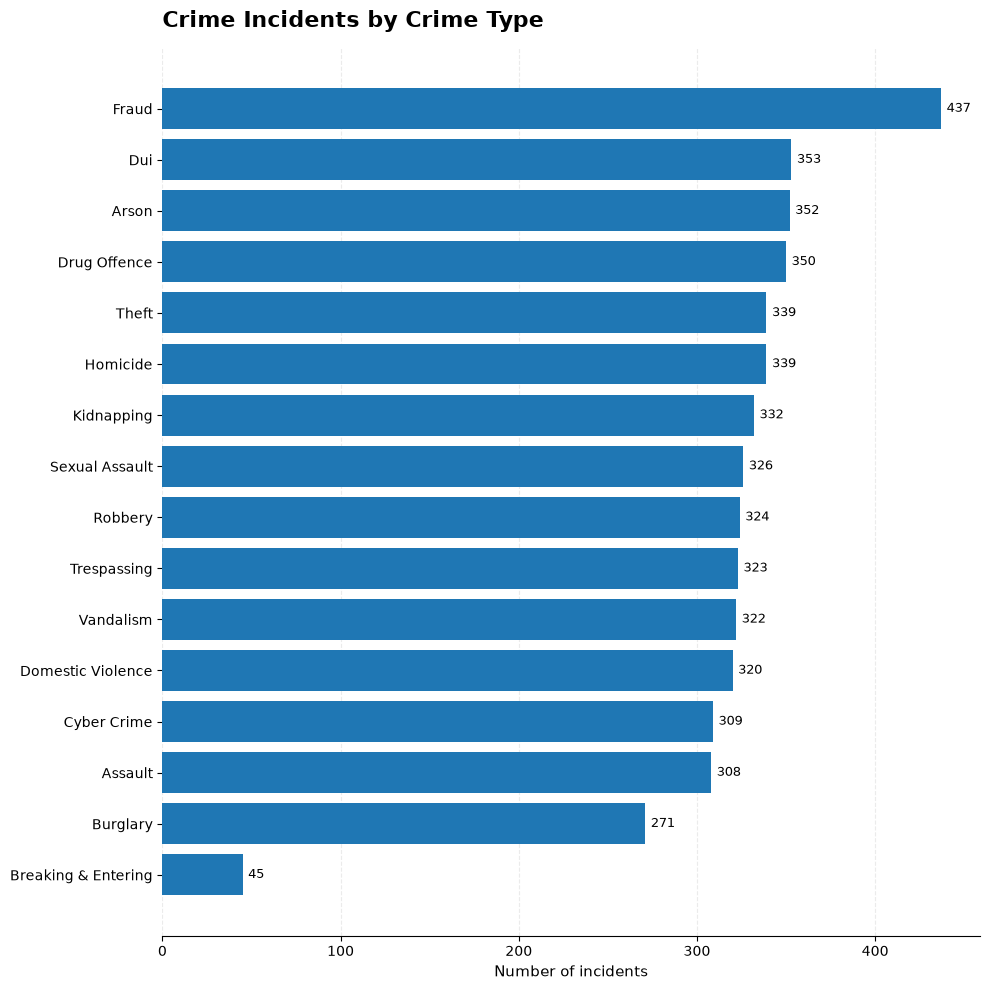

In [106]:
crime_counts = (
    df_clean["crime_type"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(
    crime_counts.index,
    crime_counts.values
)

ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in crime_counts.values],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Crime Incidents by Crime Type",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of incidents")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 2. Crime Trend Over Time

This visualization examines the annual number of recorded crime incidents from 2018 to 2024.

The year is derived from `incident_datetime` for analysis purposes and is not added as a permanent column to the cleaned dataset.


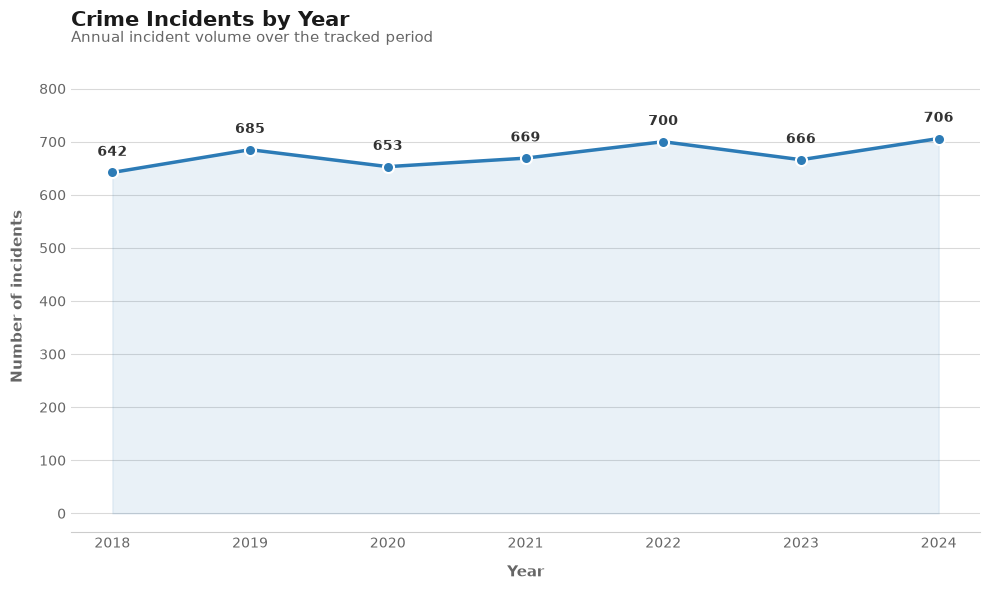

In [107]:
# 1. Setup with a slightly softer background color for a modern feel
year_counts = df_clean["incident_datetime"].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

primary_color = "#2c7bb6" # A professional, deep teal/blue

# 2. Main plot with styled markers
ax.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=2.5,
    color=primary_color,
    markersize=8,
    markeredgecolor="white",
    markeredgewidth=1.5
)

# 3. Add visual weight with a subtle fill under the line
ax.fill_between(
    year_counts.index,
    year_counts.values,
    alpha=0.1,
    color=primary_color
)

# 4. Styled Annotations
for year, value in zip(year_counts.index, year_counts.values):
    ax.annotate(
        f"{value:,}",
        (year, value),
        xytext=(0, 12), # Pushed slightly higher
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# 5. Title and Subtitle Storytelling
ax.set_title(
    "Crime Incidents by Year",
    loc="left",
    fontweight="bold",
    fontsize=15,
    color="#1a1a1a",
    pad=25
)
# Adding a subtitle for context
ax.text(
    0, 1.04,
    "Annual incident volume over the tracked period", 
    transform=ax.transAxes,
    fontsize=11,
    color="#666666"
)

# 6. Axis Labels
ax.set_xlabel("Year", color="#666666", fontweight="bold", labelpad=10)
# Optional: You can remove the ylabel entirely since the title and annotations explain it
ax.set_ylabel("Number of incidents", color="#666666", fontweight="bold", labelpad=10)

# 7. Clean up ticks and format Y-axis
ax.set_xticks(year_counts.index)
ax.tick_params(colors="#666666", which="both", length=0) # Hides tick lines, keeps labels

# Format Y-axis to 'K' (Thousands) to reduce visual clutter
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}')
)

# 8. Declutter Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False) # Hide left spine since we have grid lines
ax.spines["bottom"].set_color("#cccccc")

# 9. Softer Grid Lines
ax.grid(axis="y", linestyle="-", alpha=0.15, color="black")
ax.set_axisbelow(True)

# 10. Add padding to the top so annotations don't get cut off
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.15) 

plt.tight_layout()
plt.show()

### 3. Crime Distribution by District

This visualization compares the number of recorded incidents across districts.

The purpose is to identify differences in incident volume between districts, rather than to infer crime rates or population-adjusted risk.


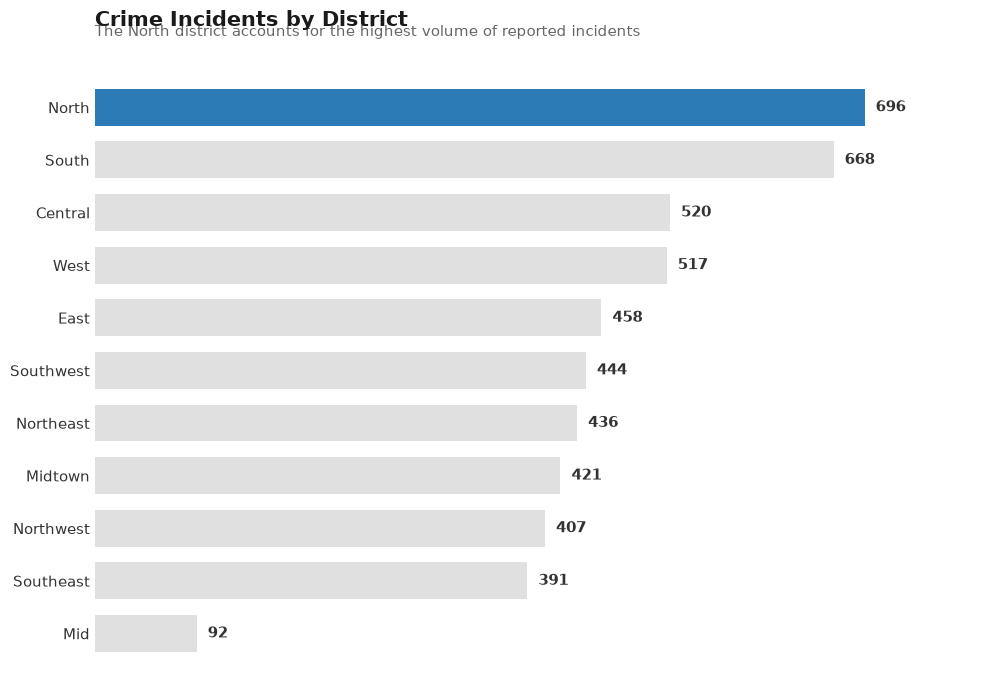

In [108]:
district_counts = df_clean["district"].value_counts().sort_values()

# 1. Clean the categorical labels (Capitalize for a professional look)
districts = district_counts.index.str.title()
values = district_counts.values

# 2. Setup figure with a clean white background
fig, ax = plt.subplots(figsize=(10, 7), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# 3. Strategic Color Palette
# Highlight the highest value, use a neutral gray for the rest
highlight_color = "#2c7bb6" 
neutral_color = "#e0e0e0"
colors = [neutral_color if val < max(values) else highlight_color for val in values]

# 4. Plot the horizontal bars
bars = ax.barh(
    districts,
    values,
    color=colors,
    edgecolor="none",
    height=0.7 # Slightly thinner bars for elegance
)

# 5. Add bold labels directly to the bars
ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in values],
    padding=8,
    fontsize=11,
    fontweight="bold",
    color="#333333"
)

# 6. Title and Subtitle Storytelling
ax.set_title(
    "Crime Incidents by District",
    loc="left",
    fontweight="bold",
    fontsize=15,
    color="#1a1a1a",
    pad=25
)
ax.text(
    0, 1.04,
    "The North district accounts for the highest volume of reported incidents",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666"
)

# 7. Extreme Data-Ink Ratio Improvement
# Hide the X-axis completely since we have direct bar labels
ax.get_xaxis().set_visible(False)

# Remove all spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove Y-axis ticks but keep the clean text labels
ax.tick_params(axis="y", which="both", length=0, labelsize=11, colors="#333333")

# 8. Dynamic right padding so the longest bar label doesn't get cut off
ax.set_xlim(0, max(values) * 1.15) 

plt.tight_layout()
plt.show()

### 4. Severity Distribution

This visualization shows the distribution of incidents across the four standardized severity categories.

The chart provides an overview of how incidents are classified by severity within the dataset.


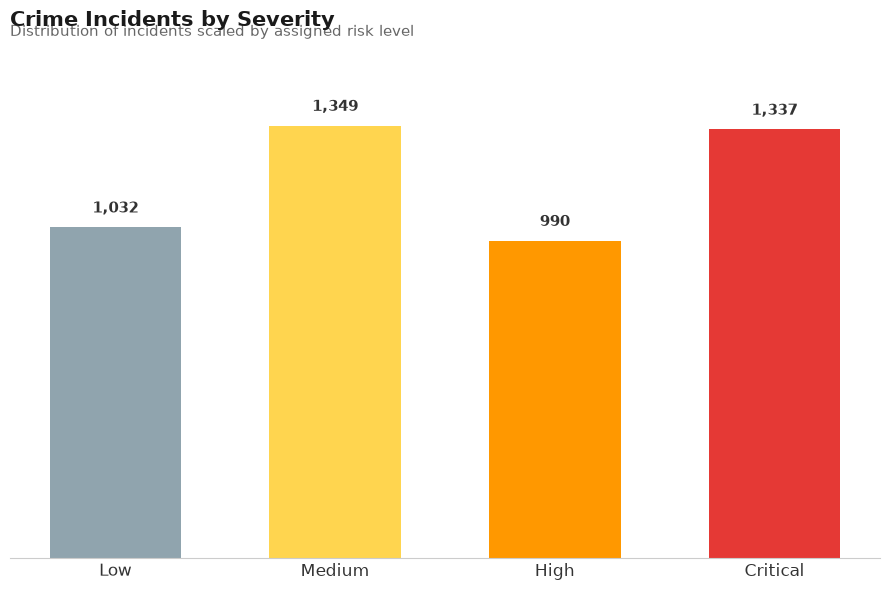

In [109]:
# 1. Define the variable from your dataframe first
severity_counts = df_clean["severity"].value_counts().reindex(["Low", "Medium", "High", "Critical"])

fig, ax = plt.subplots(figsize=(9, 6), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# 2. Semantic Color Palette (Cool/Neutral to Warm/Severe)
# Low: Gray-blue, Medium: Yellow, High: Orange, Critical: Red
severity_colors = ["#90a4ae", "#ffd54f", "#ff9800", "#e53935"]

# 3. Plot the vertical bars
bars = ax.bar(
    severity_counts.index,
    severity_counts.values,
    color=severity_colors,
    width=0.6, # Sleeker bars
    edgecolor="none"
)

# 4. Add bold labels directly above the bars
ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in severity_counts.values],
    padding=8,
    fontsize=11,
    fontweight="bold",
    color="#333333"
)

# 5. Title and Subtitle Storytelling
ax.set_title(
    "Crime Incidents by Severity",
    loc="left",
    fontweight="bold",
    fontsize=15,
    color="#1a1a1a",
    pad=25
)
ax.text(
    0, 1.05,
    "Distribution of incidents scaled by assigned risk level",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666"
)

# 6. Extreme Data-Ink Ratio Improvement
# Hide the Y-axis completely since we have direct bar labels
ax.get_yaxis().set_visible(False)
ax.set_xlabel("") # The categories speak for themselves

# Remove spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

# 7. Clean up X-axis ticks
ax.tick_params(axis="x", which="both", length=0, labelsize=12, colors="#333333")

# 8. Dynamic top padding to prevent label cutoff
ax.set_ylim(0, max(severity_counts.values) * 1.15)

plt.tight_layout()
plt.show()

### Initial EDA Findings

The initial exploration reveals several patterns in the cleaned dataset:

* Crime incidents are distributed across 35 crime types, with DUI, drug offence, and domestic violence among the most frequently recorded categories.
* Annual incident counts remain within a relatively narrow range between 2018 and 2024, with 2024 recording the highest number of incidents in the dataset.
* Incident volume differs across districts, with North and South containing the largest numbers of recorded incidents. These differences should not be interpreted as crime rates without population or exposure data.
* Medium and Critical incidents represent substantial portions of the dataset, while High incidents are comparatively less frequent.

These observations describe patterns within the dataset and should not be interpreted as causal relationships.


### 5. Incident Timing

This visualization examines the distribution of recorded incidents across the 24 hours of the day.

The hour is derived from `incident_datetime`. Records with missing datetime values are excluded from this analysis.

The purpose is to identify periods of the day with relatively higher or lower incident volume.


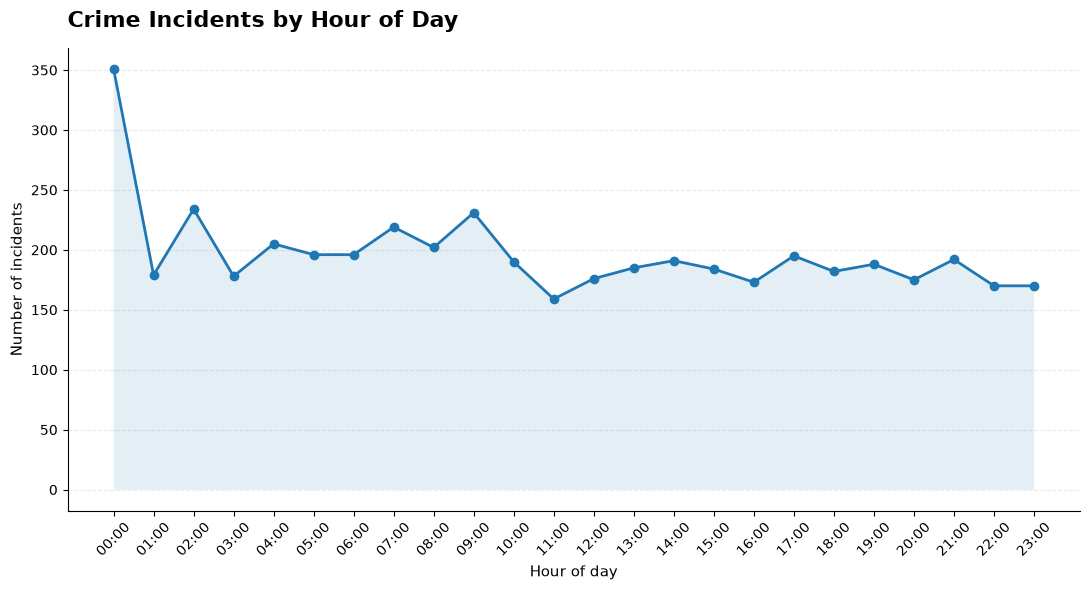

In [110]:
hour_counts = (
    df_clean["incident_datetime"]
    .dt.hour
    .value_counts()
    .sort_index()
)

# Make sure all 24 hours are represented
hour_counts = hour_counts.reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    hour_counts.index,
    hour_counts.values,
    marker="o",
    linewidth=2
)

ax.fill_between(
    hour_counts.index,
    hour_counts.values,
    alpha=0.12
)

ax.set_title(
    "Crime Incidents by Hour of Day",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of incidents")

ax.set_xticks(range(24))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(24)], rotation=45)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 6. Age Distribution

#### 6.1 Suspect Age Distribution

This histogram shows the distribution of recorded suspect ages after invalid values were removed during the cleaning process.

The median age is shown as a reference point to provide additional context for the distribution.


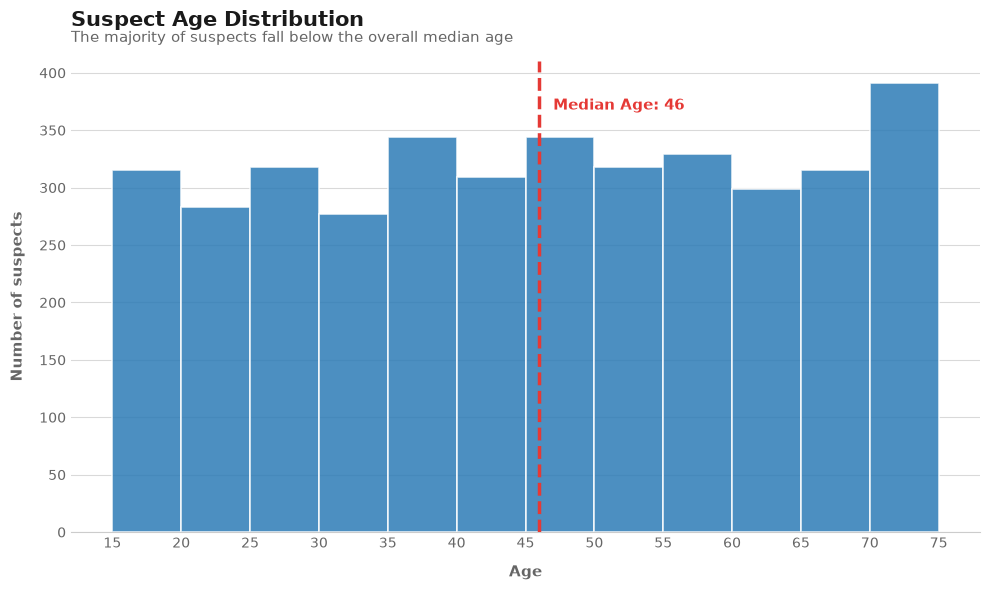

In [111]:
suspect_age = df_clean["suspect_age"].dropna()

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

primary_color = "#2c7bb6"
median_color = "#e53935" # Strong red to draw the eye

bins = np.arange(15, 76, 5)

# 1. Plot the histogram with slight transparency and crisp edges
counts, edges, patches = ax.hist(
    suspect_age,
    bins=bins,
    color=primary_color,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.85 
)

# 2. Add the median line
median_suspect_age = suspect_age.median()

ax.axvline(
    median_suspect_age,
    color=median_color,
    linestyle="--",
    linewidth=2.5,
    zorder=3 # Ensures the line is drawn on top of the bars
)

# 3. Direct Labeling (Replacing the Legend)
# Place the text dynamically near the top of the highest bar
max_count = counts.max()
ax.annotate(
    f"Median Age: {median_suspect_age:.0f}",
    xy=(median_suspect_age, max_count * 0.95),
    xytext=(10, 0), # Offset 10 points to the right
    textcoords="offset points",
    va="center",
    color=median_color,
    fontweight="bold",
    fontsize=11
)

# 4. Title and Subtitle Storytelling
ax.set_title(
    "Suspect Age Distribution",
    loc="left",
    fontweight="bold",
    fontsize=15,
    color="#1a1a1a",
    pad=25
)
ax.text(
    0, 1.04,
    "The majority of suspects fall below the overall median age",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666"
)

# 5. Axis Formatting
ax.set_xlabel("Age", color="#666666", fontweight="bold", labelpad=10)
ax.set_ylabel("Number of suspects", color="#666666", fontweight="bold", labelpad=10)

# Align x-ticks exactly with the bin edges for perfect readability
ax.set_xticks(bins)
ax.tick_params(colors="#666666", which="both", length=0)

# 6. Declutter Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

# 7. Grid Setup
ax.grid(axis="y", linestyle="-", alpha=0.15, color="black")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### 6.2 Victim Age Distribution

This histogram shows the distribution of recorded victim ages after invalid values were removed during the cleaning process.

The median age is shown to provide a reference point for the center of the distribution.


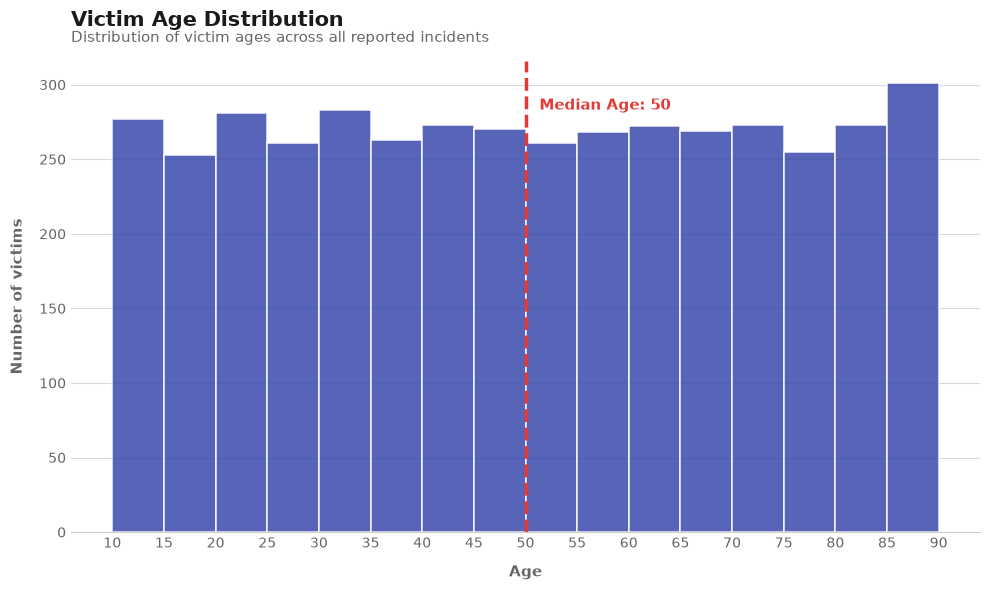

In [112]:
victim_age = df_clean["victim_age"].dropna()

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# A distinct color (Indigo) to separate Victim data from Suspect data (Blue)
primary_color = "#3949ab" 
median_color = "#e53935"

bins = np.arange(10, 91, 5)

# 1. Plot the histogram
counts, edges, patches = ax.hist(
    victim_age,
    bins=bins,
    color=primary_color,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.85 
)

# 2. Calculate and plot the median line
median_victim_age = victim_age.median()

ax.axvline(
    median_victim_age,
    color=median_color,
    linestyle="--",
    linewidth=2.5,
    zorder=3
)

# 3. Direct Labeling for the Median
max_count = counts.max()
ax.annotate(
    f"Median Age: {median_victim_age:.0f}",
    xy=(median_victim_age, max_count * 0.95),
    xytext=(10, 0),
    textcoords="offset points",
    va="center",
    color=median_color,
    fontweight="bold",
    fontsize=11
)

# 4. Contextual Titles
ax.set_title(
    "Victim Age Distribution",
    loc="left",
    fontweight="bold",
    fontsize=15,
    color="#1a1a1a",
    pad=25
)
ax.text(
    0, 1.04,
    "Distribution of victim ages across all reported incidents",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666"
)

# 5. Clean Axis Labels and Ticks
ax.set_xlabel("Age", color="#666666", fontweight="bold", labelpad=10)
ax.set_ylabel("Number of victims", color="#666666", fontweight="bold", labelpad=10)

ax.set_xticks(bins)
ax.tick_params(colors="#666666", which="both", length=0)

# 6. Declutter Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

# 7. Background Grid
ax.grid(axis="y", linestyle="-", alpha=0.15, color="black")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 7. Property Loss by Crime Type

This analysis compares median reported property loss across crime types.

The median is used instead of the mean because it provides a more robust measure of the typical property loss when distributions may contain unusually high or low values.

Only crime types with at least 100 valid property-loss observations are included to provide a more comparable basis across categories.


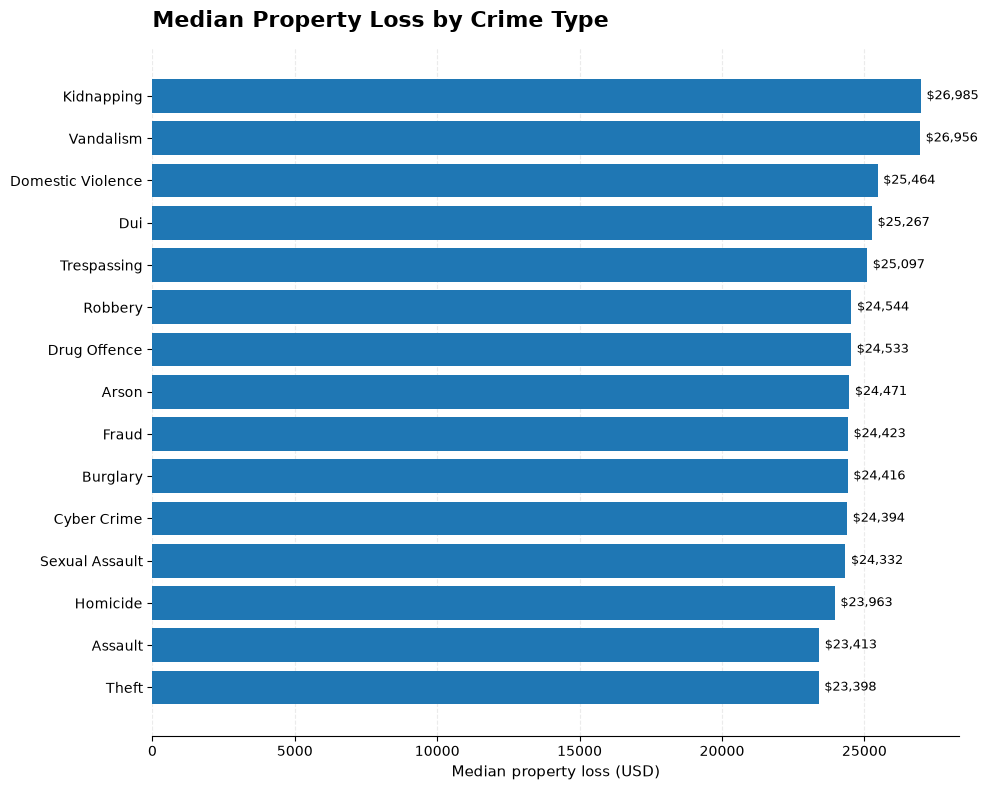

In [113]:
property_loss_by_crime = (
    df_clean
    .dropna(subset=["property_loss_usd"])
    .groupby("crime_type")["property_loss_usd"]
    .agg(
        median="median",
        count="count"
    )
)

property_loss_by_crime = (
    property_loss_by_crime[
        property_loss_by_crime["count"] >= 100
    ]
    .sort_values("median")
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    property_loss_by_crime.index,
    property_loss_by_crime["median"]
)

ax.bar_label(
    bars,
    labels=[
        f"${value:,.0f}"
        for value in property_loss_by_crime["median"]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Median Property Loss by Crime Type",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Median property loss (USD)")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 8. Average Arrests by Crime Type

This analysis compares the average number of arrests across crime types.

Only crime types with at least 100 valid arrest observations are included to reduce the influence of categories with very small sample sizes.

The metric represents the average number of arrests recorded per incident in the dataset.


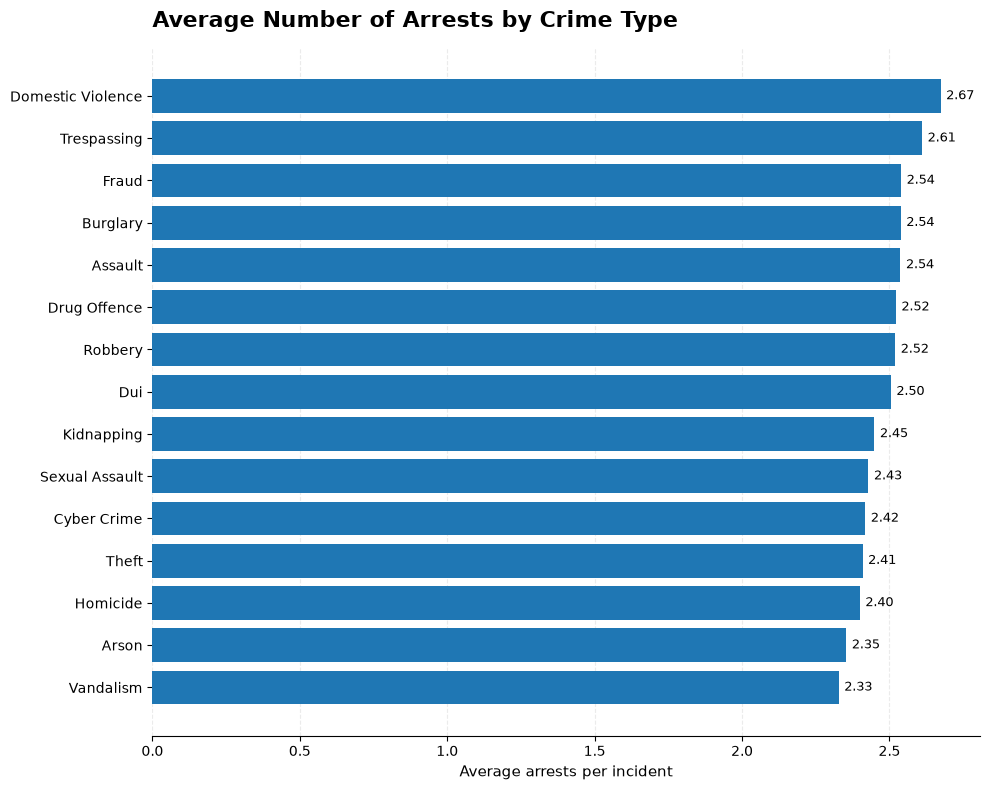

In [114]:
arrests_by_crime = (
    df_clean
    .dropna(subset=["num_arrests"])
    .groupby("crime_type")["num_arrests"]
    .agg(
        mean="mean",
        count="count"
    )
)

arrests_by_crime = (
    arrests_by_crime[
        arrests_by_crime["count"] >= 100
    ]
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    arrests_by_crime.index,
    arrests_by_crime["mean"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in arrests_by_crime["mean"]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Average Number of Arrests by Crime Type",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Average arrests per incident")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Analytical EDA Findings

The analytical exploration provides several additional observations:

* Incident records are not evenly distributed across the 24-hour period, with some hours showing substantially higher recorded incident volumes than others.
* Suspect ages are concentrated around the middle of the 15–75 age range, while victim ages span a wider range from 10 to 90.
* Median property loss differs across crime types, although the magnitude of the differences should be interpreted within the context of the available observations.
* Average arrests vary across crime types, but the observed averages remain within a relatively narrow range.
* Filtering categories based on a minimum number of valid observations helps reduce misleading comparisons between well-represented and sparsely represented crime types.

These findings describe patterns observed in the dataset and should not be interpreted as causal relationships.


## 9. Relationship Analysis

This section examines relationships between multiple variables to identify differences in incident characteristics across crime types, districts, time periods, and severity levels.

Unlike the previous descriptive visualizations, these analyses compare variables simultaneously to provide more detailed insights into patterns within the dataset.

The analysis focuses on distributions and associations observed in the data and does not imply causal relationships.


### 9.1 Crime Type × Severity

This analysis examines the severity composition of the most frequently recorded crime types.

The top 15 crime types by incident volume are selected to improve readability. Percentages are calculated within each crime type using only records with non-missing severity values.

This allows the analysis to compare the severity composition of different crime types rather than simply comparing their total incident counts.


In [115]:
severity_order = ["Low", "Medium", "High", "Critical"]

top_crimes = (
    df_clean["crime_type"]
    .value_counts()
    .head(15)
    .index
)

crime_severity = pd.crosstab(
    df_clean.loc[
        df_clean["crime_type"].isin(top_crimes),
        "crime_type"
    ],
    df_clean.loc[
        df_clean["crime_type"].isin(top_crimes),
        "severity"
    ],
    normalize="index"
) * 100

crime_severity = crime_severity.reindex(
    columns=severity_order,
    fill_value=0
)

crime_severity = crime_severity.sort_values(
    "Critical",
    ascending=True
)

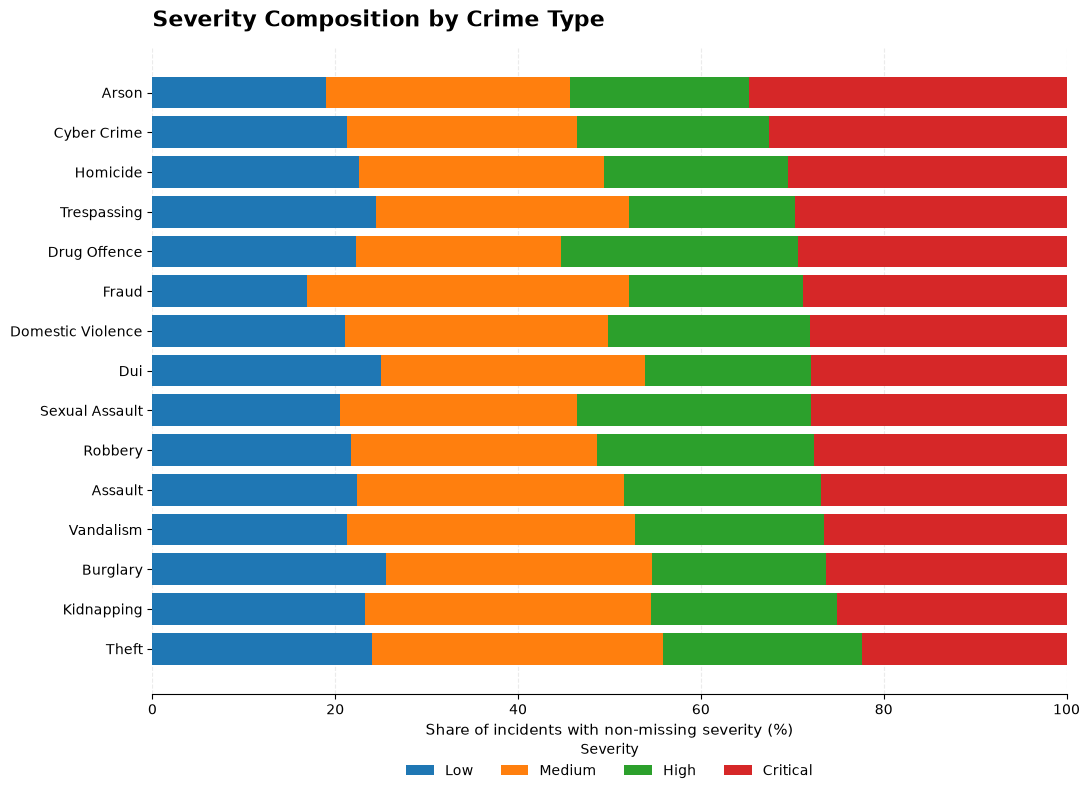

In [116]:
fig, ax = plt.subplots(figsize=(11, 8))

left = np.zeros(len(crime_severity))

for severity in severity_order:
    values = crime_severity[severity].values

    ax.barh(
        crime_severity.index,
        values,
        left=left,
        label=severity
    )

    left += values

ax.set_title(
    "Severity Composition by Crime Type",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Share of incidents with non-missing severity (%)")
ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.legend(
    title="Severity",
    frameon=False,
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 9.2 District × Severity

This analysis compares the severity composition of incidents across districts.

A 100% stacked bar chart is used so that districts can be compared based on their severity proportions rather than their total incident volumes.

Missing severity values are excluded from the percentage calculation.


In [117]:
district_severity = pd.crosstab(
    df_clean["district"],
    df_clean["severity"],
    normalize="index"
) * 100

district_severity = district_severity.reindex(
    columns=severity_order,
    fill_value=0
)

district_total = (
    df_clean.dropna(subset=["severity"])
    .groupby("district")
    .size()
    .reindex(district_severity.index)
)

district_severity["valid_n"] = district_total

district_severity = district_severity.sort_values(
    "valid_n",
    ascending=True
)

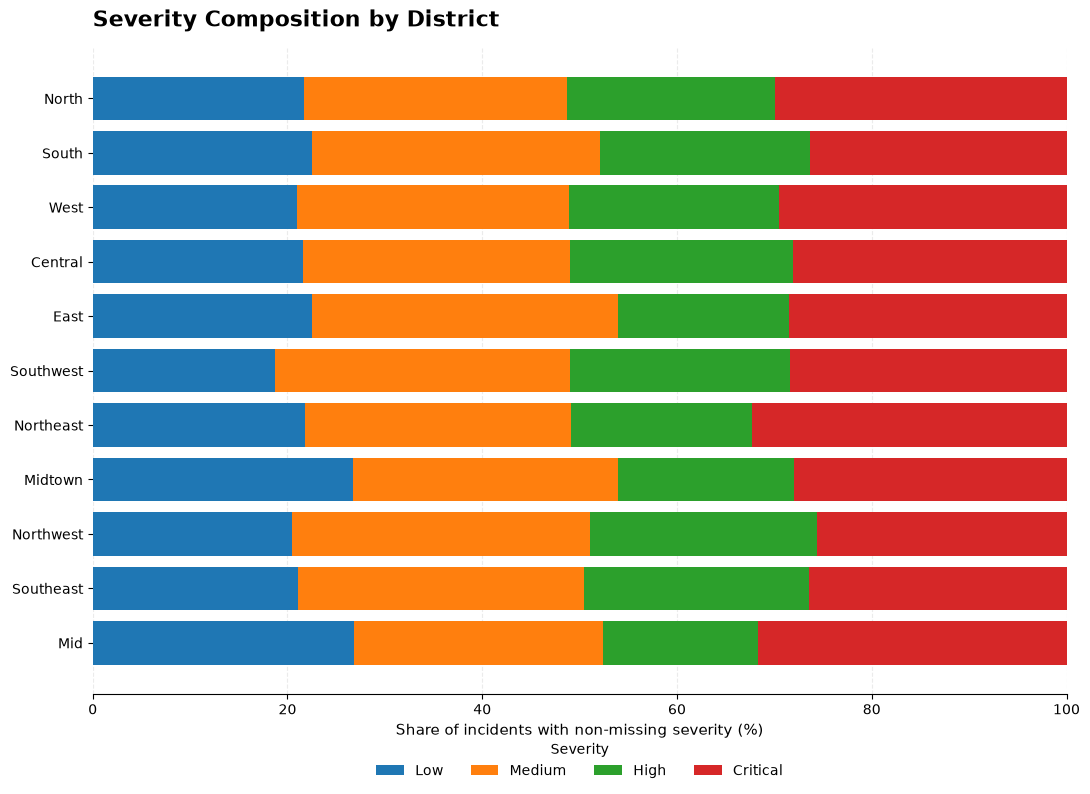

In [118]:
plot_data = district_severity.drop(columns="valid_n")

fig, ax = plt.subplots(figsize=(11, 8))

left = np.zeros(len(plot_data))

for severity in severity_order:
    values = plot_data[severity].values

    ax.barh(
        plot_data.index,
        values,
        left=left,
        label=severity
    )

    left += values

ax.set_title(
    "Severity Composition by District",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Share of incidents with non-missing severity (%)")
ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.legend(
    title="Severity",
    frameon=False,
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 9.3 Crime Type × Time of Day

This analysis examines how the distribution of incidents across the day varies by crime type.

The day is divided into four analytical periods based on incident hour:

* Night: 00:00–05:59
* Morning: 06:00–11:59
* Afternoon: 12:00–17:59
* Evening: 18:00–23:59

The periods are analytical groupings created for this analysis and are not original fields in the dataset.

The 10 most frequently recorded crime types are used to keep the visualization readable.


In [119]:
time_period = pd.cut(
    df_clean["incident_datetime"].dt.hour,
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "Night",
        "Morning",
        "Afternoon",
        "Evening"
    ]
)

top_10_crimes = (
    df_clean["crime_type"]
    .value_counts()
    .head(10)
    .index
)

crime_time = pd.crosstab(
    df_clean.loc[
        df_clean["crime_type"].isin(top_10_crimes),
        "crime_type"
    ],
    time_period.loc[
        df_clean["crime_type"].isin(top_10_crimes)
    ],
    normalize="index"
) * 100

time_order = [
    "Night",
    "Morning",
    "Afternoon",
    "Evening"
]

crime_time = crime_time.reindex(
    columns=time_order,
    fill_value=0
)

crime_time = crime_time.sort_values(
    "Night",
    ascending=True
)

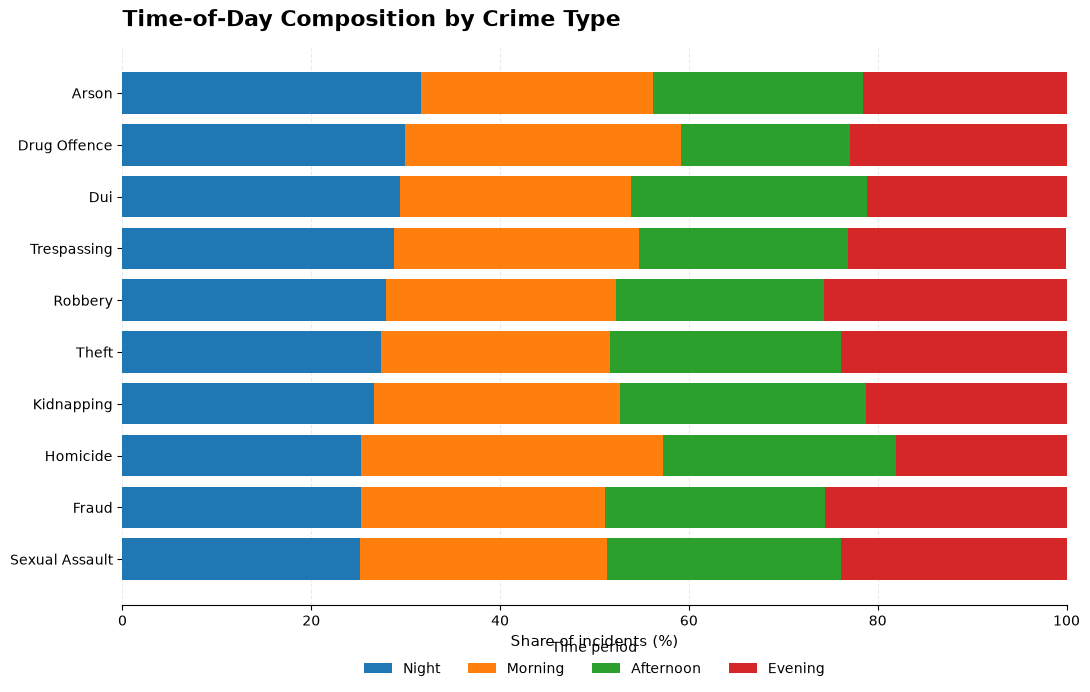

In [120]:
fig, ax = plt.subplots(figsize=(11, 7))

left = np.zeros(len(crime_time))

for period in time_order:
    values = crime_time[period].values

    ax.barh(
        crime_time.index,
        values,
        left=left,
        label=period
    )

    left += values

ax.set_title(
    "Time-of-Day Composition by Crime Type",
    loc="left",
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Share of incidents (%)")
ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.legend(
    title="Time period",
    frameon=False,
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 9.4 Severity × Property Loss

This analysis examines the distribution of reported property loss across severity categories.

A boxplot is used to compare the median, spread, and potential outliers of property-loss values within each severity category.

Only records with both valid severity and property-loss values are included.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12180\1020850969.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


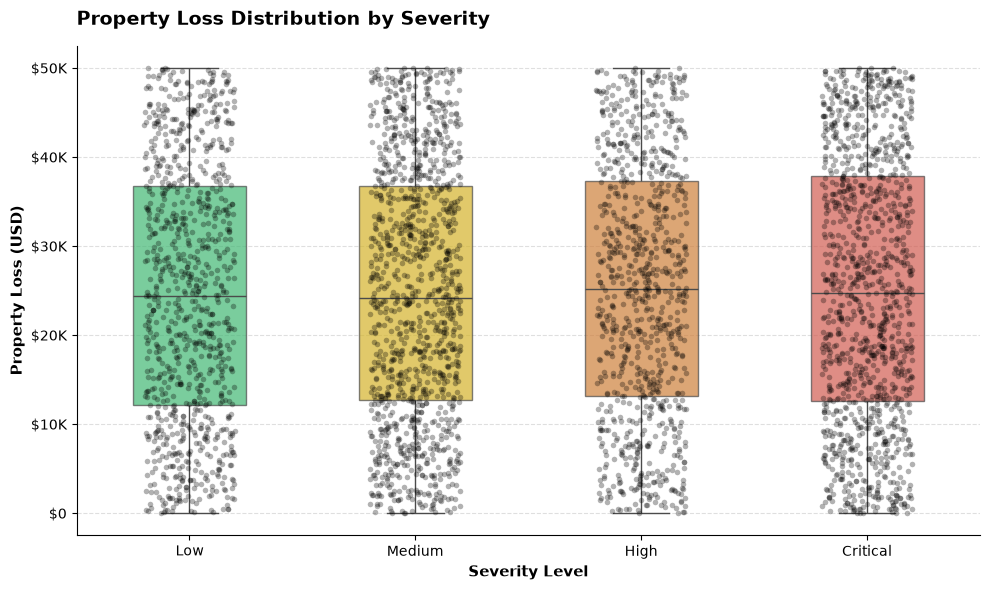

In [121]:
# 1. Define order and an intuitive color palette (Green -> Red)
severity_order = ["Low", "Medium", "High", "Critical"]
severity_colors = {"Low": "#2ecc71", "Medium": "#f1c40f", "High": "#e67e22", "Critical": "#e74c3c"}

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Base Boxplot (using seaborn removes the need for list comprehensions)
sns.boxplot(
    data=df_clean,
    x="severity",
    y="property_loss_usd",
    order=severity_order,
    palette=severity_colors,
    showfliers=False,         # Hide default fliers so they don't clash with stripplot
    width=0.5,
    boxprops=dict(alpha=0.7), # Add transparency to make overlay pop
    ax=ax
)

# 3. Add Stripplot overlay to visualize actual data density and distribution
sns.stripplot(
    data=df_clean,
    x="severity",
    y="property_loss_usd",
    order=severity_order,
    color="black",
    alpha=0.3,      # Make dots semi-transparent
    jitter=0.2,     # Spread points out horizontally
    size=4,
    ax=ax
)

# 4. Format Y-axis for financial readability ($1.5M instead of 1500000)
def currency_format(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:,.0f}'

ax.yaxis.set_major_formatter(FuncFormatter(currency_format))

# 5. Styling and labels
ax.set_title("Property Loss Distribution by Severity", loc="left", fontweight="bold", fontsize=14, pad=15)
ax.set_xlabel("Severity Level", fontweight="bold")
ax.set_ylabel("Property Loss (USD)", fontweight="bold")

# Clean up axes
sns.despine(ax=ax) # Replaces manually hiding top/right spines
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Relationship Analysis Findings

The relationship analysis provides several additional observations:

* The severity composition differs across crime types, indicating that incident volume alone does not fully describe the distribution of severity.
* Severity composition also varies across districts, although smaller districts should be interpreted cautiously because they contain fewer observations.
* Crime types exhibit different time-of-day compositions, suggesting that incident timing is not uniformly distributed across categories.
* Reported property loss has relatively similar central values across severity categories, indicating that severity classification and property loss do not show a large difference in their observed medians in this dataset.

These findings describe associations observed within the dataset and should not be interpreted as evidence of causality.


# Key Findings

The exploratory analysis of the cleaned crime dataset reveals several notable patterns.

### 1. Crime Distribution

The dataset contains 35 standardized crime types. DUI, drug offence, and domestic violence are among the most frequently recorded categories, while several other categories occur considerably less often.

### 2. Annual Incident Volume

The number of recorded incidents remains within a relatively narrow range between 2018 and 2024. The dataset contains 642 incidents in 2018 and 706 incidents in 2024, with moderate fluctuations between years.

### 3. Geographic Distribution

Incident volumes differ across districts. North and South contain the largest numbers of recorded incidents, while `mid` contains substantially fewer records than the other districts.

These differences represent the number of records in the dataset and should not be interpreted as crime rates because population or exposure data are not available.

### 4. Severity Composition

Medium and Critical incidents represent substantial portions of the dataset. The severity composition also differs across crime types and districts, indicating that incident frequency alone does not fully describe the distribution of severity.

### 5. Temporal Patterns

Incident records are not evenly distributed across the 24-hour day. Midnight has the highest recorded incident volume among individual hours, while several early-morning and daytime hours have lower volumes.

Crime types also show differences in their time-of-day composition.

### 6. Age Distribution

Recorded suspect ages are concentrated around the middle of the 15–75 valid range, with a median age of 46. Victim ages cover a wider range from 10 to 90, with a median age of 50.

### 7. Property Loss

Median reported property loss varies across crime types. However, the central values of property loss are relatively similar across severity categories, suggesting that severity and reported financial loss show limited separation in this dataset.

### 8. Arrests

The average number of arrests varies across crime types, but the differences remain relatively modest among categories with sufficient observations.

Overall, the analysis demonstrates that crime frequency, severity, location, timing, and financial impact provide different perspectives on the same dataset and should be considered together rather than interpreted in isolation.


In [122]:
eda_summary = {
    "Total incidents": len(df_clean),
    "Crime types": df_clean["crime_type"].nunique(),
    "Districts": df_clean["district"].nunique(),
    "Cities": df_clean["city"].nunique(),
    "Highest-volume crime": df_clean["crime_type"].value_counts().idxmax(),
    "Highest-volume district": df_clean["district"].value_counts().idxmax(),
    "Highest-volume year": df_clean["incident_datetime"].dt.year.value_counts().idxmax(),
    "Most common severity": df_clean["severity"].value_counts().idxmax()
}

pd.Series(eda_summary)

Total incidents              5050
Crime types                    16
Districts                      11
Cities                          8
Highest-volume crime        Fraud
Highest-volume district     North
Highest-volume year        2024.0
Most common severity       Medium
dtype: object

# Conclusion & Limitations

## Conclusion

This project demonstrates a complete data-cleaning and exploratory-analysis workflow using Python and Pandas.

Starting from 5,250 records and 33 columns, the dataset was cleaned through duplicate removal, datetime standardization, numerical validation, geographic correction, categorical standardization, text normalization, and data-type conversion.

After cleaning, the final dataset contains **5,050 records and 33 columns**. All defined validation checks passed, including duplicate detection, numerical range checks, geographic coordinate validation, property-loss validation, and future-date validation.

The exploratory analysis then examined crime frequency, annual trends, geographic distribution, severity, incident timing, age distributions, property loss, arrests, and relationships between selected variables.

An important principle throughout the project was to avoid unsupported assumptions. When values could not be reliably recovered, they were retained as missing rather than being artificially reconstructed.

## Limitations

The dataset is synthetic and therefore should not be interpreted as a representation of real-world crime patterns.

The analysis also has several limitations:

* Population-level crime rates cannot be calculated because population or exposure data are not provided.
* Some identifier-to-attribute relationships remain inconsistent in the source data and were not forcibly reconstructed.
* Missing values remain in several columns because reliable imputation was not possible.
* Some category distinctions were intentionally preserved when merging them would require unsupported assumptions.
* The defined age ranges and other validation rules are analytical assumptions based on the observed dataset and should not be treated as universal domain standards.

Therefore, the findings describe patterns within this dataset rather than causal explanations or real-world crime statistics.


# Export Clean Dataset

The validated dataset is exported as a CSV file for further analysis or reuse.

The exported file contains the cleaned records and retains the final data types and missing-value representation required for downstream analysis.


In [123]:
output_file = "cleaned_crime_dataset.csv"

df_clean.to_csv(
    output_file,
    index=False
)

print(f"Dataset exported to: {output_file}")

Dataset exported to: cleaned_crime_dataset.csv


In [124]:
df_exported = pd.read_csv(output_file)

print("Exported shape:", df_exported.shape)
print("File exists:", output_file)

Exported shape: (5050, 33)
File exists: cleaned_crime_dataset.csv


In [125]:
assert df_exported.shape == df_clean.shape
assert df_exported.columns.tolist() == df_clean.columns.tolist()

print("Export verification passed.")

Export verification passed.
